# Bloom / CEP - ingestao dos QA pairs

Le os artefatos `*_cep_qa.json` de `results/<RUN_ID>/cep/outputs/`
(`RUN_ID` default `thesis-run-01`, sobrescrevivel pela env `ARANDU_RUN_ID`) e monta
um `DataFrame` com **uma linha por par QA**, achatando:

- metadados da fonte (`source_*`, arquivo, local, data da gravacao);
- campos de geracao do par (bloom, tipo, multi-hop, chunk);
- os criterios do validador CEP (`faithfulness`, `bloom_calibration`,
  `informativeness`, `self_containedness`) em colunas `score_*` / `thr_*`.

Aplica um **piso de tamanho de chunk** (`MIN_CHUNK_CHARS`) na ingestão: o
chunker `cep_4k` emite o resto da última janela sem piso, então a cauda tem
chunks de 24 a 60 caracteres. Nenhum deles é documento curto (o menor do
corpus tem 215 caracteres), são sobras de documentos saudáveis, e como o
gerador pede a escada de Bloom completa de qualquer chunk, esses restos
contaminam as contagens com pares sem base textual. O descarte é reportado
chunk por chunk em vez de silencioso.

Requer o extra `analysis` (pandas): `uv sync --extra analysis`.

In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path
from typing import Any

import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS_ROOT = Path(os.environ.get("ARANDU_RESULTS_BASE_DIR", REPO_ROOT / "results"))

# Parametro do notebook: troque o run-id (ou exporte ARANDU_RUN_ID) para
# analisar outra execucao sem tocar no resto das celulas.
RUN_ID = os.environ.get("ARANDU_RUN_ID", "thesis-run-01")


def cep_outputs_dir(run_id: str = RUN_ID, results_root: Path = RESULTS_ROOT) -> Path:
    """Resolve o diretorio de saidas do estagio CEP de um run.

    Args:
        run_id: Identificador do run em `results/`.
        results_root: Raiz do diretorio de resultados.

    Returns:
        Caminho `results/<run-id>/cep/outputs/`.
    """
    return results_root / run_id / "cep" / "outputs"


def available_runs(results_root: Path = RESULTS_ROOT) -> list[str]:
    """Lista os run-ids que possuem saidas do estagio CEP.

    Args:
        results_root: Raiz do diretorio de resultados.

    Returns:
        Run-ids ordenados com ao menos um arquivo `*_cep_qa.json`.
    """
    return sorted(
        path.parent.parent.name
        for path in results_root.glob("*/cep/outputs")
        if any(path.glob("*_cep_qa.json"))
    )


CEP_DIR = cep_outputs_dir()

# Campos de texto longo descartados do DataFrame (ficam so como tamanho).
HEAVY_FIELDS = ("context", "generation_prompt", "generation_thinking")

# Piso de tamanho de chunk. O chunker `cep_4k` fatia em janelas de 4000
# caracteres e emite o resto sem piso, entao a cauda tem chunks de 24 a 60
# caracteres. Nenhum deles e documento curto: sao sobras de documentos
# saudaveis (o menor documento do corpus tem 215 caracteres). Como o gerador
# pede a escada de Bloom completa de qualquer chunk, esses restos entram na
# contagem sem base textual para sustentar um par, e os aprovados que produzem
# sao eco do bloco de metadados. Ficam fora de toda a analise.
MIN_CHUNK_CHARS = 100

CEP_FILES = sorted(CEP_DIR.glob("*_cep_qa.json"))
print(f"runs com saida CEP: {available_runs()}")
RUN_ID, CEP_DIR, len(CEP_FILES)

runs com saida CEP: ['thesis-run-01']


('thesis-run-01',
 PosixPath('/home/fred/Workspace/mastering/arandu/results/thesis-run-01/cep/outputs'),
 214)

In [2]:
def _criterion_columns(pair: dict[str, Any]) -> dict[str, Any]:
    """Achata os criterios do validador CEP em colunas planas.

    Args:
        pair: Par QA bruto, como serializado no arquivo `*_cep_qa.json`.

    Returns:
        Mapa com `score_<criterio>` e `thr_<criterio>` para cada criterio
        avaliado, mais `rejected_at` e `passed` do estagio de validacao.
    """
    validation = pair.get("validation") or {}
    stages = validation.get("stage_results") or {}
    scores = (stages.get("cep_validation") or {}).get("criterion_scores") or {}

    columns: dict[str, Any] = {
        "passed": validation.get("passed"),
        "rejected_at": validation.get("rejected_at"),
    }
    for name, criterion in scores.items():
        columns[f"score_{name}"] = criterion.get("score")
        columns[f"thr_{name}"] = criterion.get("threshold")
    return columns


def _flatten_pair(doc: dict[str, Any], pair: dict[str, Any]) -> dict[str, Any]:
    """Monta a linha de um par QA com os metadados do documento de origem.

    Args:
        doc: Documento `*_cep_qa.json` completo.
        pair: Um item de `doc["qa_pairs"]`.

    Returns:
        Linha plana pronta para virar registro de `DataFrame`.
    """
    meta = doc.get("source_metadata") or {}
    row: dict[str, Any] = {
        "source_gdrive_id": doc.get("source_gdrive_id"),
        "source_filename": doc.get("source_filename"),
        "location": meta.get("location"),
        "recording_date": meta.get("recording_date"),
        "event_context": meta.get("event_context"),
        "extraction_confidence": meta.get("extraction_confidence"),
        "model_id": doc.get("model_id"),
        "validator_model_id": doc.get("validator_model_id"),
        "chunker_id": doc.get("chunker_id"),
        "language": doc.get("language"),
        "cep_version": doc.get("cep_version"),
        "generation_timestamp": doc.get("generation_timestamp"),
        "doc_total_pairs": doc.get("total_pairs"),
        "doc_validated_pairs": doc.get("validated_pairs"),
        "doc_validation_rate": doc.get("validation_rate"),
    }
    row.update({k: v for k, v in pair.items() if k not in HEAVY_FIELDS and k != "validation"})
    row.update({f"{field}_chars": len(pair.get(field) or "") for field in HEAVY_FIELDS})
    row.update(_criterion_columns(pair))
    return row


def load_cep_pairs(cep_dir: Path | None = None) -> pd.DataFrame:
    """Le todos os artefatos CEP de um diretorio e retorna um par QA por linha.

    Args:
        cep_dir: Diretorio `results/<run-id>/cep/outputs/`. Por padrao, o
            do `RUN_ID` corrente.

    Returns:
        `DataFrame` com uma linha por par QA e colunas achatadas de fonte,
        geracao e validacao.

    Raises:
        FileNotFoundError: Se o diretorio nao contiver arquivos `*_cep_qa.json`.
    """
    cep_dir = cep_dir or CEP_DIR
    files = sorted(cep_dir.glob("*_cep_qa.json"))
    if not files:
        raise FileNotFoundError(f"Nenhum *_cep_qa.json em {cep_dir}")

    rows: list[dict[str, Any]] = []
    for path in files:
        doc = json.loads(path.read_text(encoding="utf-8"))
        rows.extend(_flatten_pair(doc, pair) for pair in doc.get("qa_pairs", []))

    df = pd.DataFrame(rows)
    df["generation_timestamp"] = pd.to_datetime(df["generation_timestamp"], errors="coerce")
    for column in ("bloom_level", "question_type", "location", "rejected_at"):
        df[column] = df[column].astype("category")
    return df


def drop_tiny_chunks(
    pairs: pd.DataFrame, min_chars: int = MIN_CHUNK_CHARS
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Remove os pares vindos de chunks abaixo do piso de tamanho.

    Filtra por chunk, nao por par: se o chunk entra, entram todos os seus 6
    pares, e o denominador de qualquer taxa continua sendo a escada completa.

    Args:
        pairs: DataFrame de pares QA produzido por `load_cep_pairs`.
        min_chars: Tamanho minimo de contexto, em caracteres, para o chunk
            entrar na analise.

    Returns:
        Par (`mantidos`, `descartados`): o primeiro com os pares que ficam, o
        segundo com um resumo por chunk removido (`source_gdrive_id`,
        `source_filename`, `context_chars`, `pares`), para o descarte ficar
        auditavel em vez de silencioso.
    """
    pequeno = pairs["context_chars"] < min_chars
    descartados = (
        pairs[pequeno]
        .groupby("chunk_id", observed=True)
        .agg(
            source_gdrive_id=("source_gdrive_id", "first"),
            source_filename=("source_filename", "first"),
            context_chars=("context_chars", "max"),
            pares=("context_chars", "size"),
        )
        .sort_values("context_chars")
    )
    return pairs[~pequeno].reset_index(drop=True), descartados

In [3]:
bruto = load_cep_pairs()
df, chunks_descartados = drop_tiny_chunks(bruto)

print(f"[{RUN_ID}] {bruto['source_gdrive_id'].nunique()} documentos"
      f" · {bruto['chunk_id'].nunique()} chunks · {len(bruto)} pares QA gerados")
print(f"piso de {MIN_CHUNK_CHARS} chars: {len(chunks_descartados)} chunks removidos"
      f" ({int(chunks_descartados['pares'].sum())} pares)")
print(f"analise: {df['source_gdrive_id'].nunique()} documentos"
      f" · {df['chunk_id'].nunique()} chunks · {len(df)} pares")

# Todo chunk removido tem irmaos no mesmo documento, entao nenhum documento
# sai do corpus com o filtro. Se essa contagem mudar, o piso passou a descartar
# documento inteiro e a decisao precisa ser revista.
assert df["source_gdrive_id"].nunique() == bruto["source_gdrive_id"].nunique()

display(chunks_descartados)
df.head()

[thesis-run-01] 214 documentos · 445 chunks · 2670 pares QA gerados
piso de 100 chars: 3 chunks removidos (18 pares)
analise: 214 documentos · 442 chunks · 2652 pares


,source_gdrive_id,source_filename,context_chars,pares
chunk_id,,,,
3f7ca42c5bcce6c4,1rAwXptR47e-_nUIdcbtbI8N1qUOu184A,VID_20250718_102720450.mp4,24,6
38b8b0cebefb8e88,1Iq-BExRG5X7lXmBqgLxLcAeUVmUPciHP,MVI_8683.MOV,59,6
f610957c458f6796,1UedB859RjifjCbCKwhaa5mHDYhxMnptJ,Dani Borges 31-10-2025.MVI.MOV,60,6


,source_gdrive_id,source_filename,location,recording_date,event_context,extraction_confidence,model_id,validator_model_id,chunker_id,language,...,passed,rejected_at,score_faithfulness,thr_faithfulness,score_bloom_calibration,thr_bloom_calibration,score_informativeness,thr_informativeness,score_self_containedness,thr_self_containedness
0,1-ZWwPv7DM458HviU5UkJgJEHzVXan0la,MVI_8624.MOV,BALSA,23-04-2026,Aida- 23-04-2026 Dani Borges,0.5,qwen3:14b,qwen3:14b,cep_4k,pt,...,True,NaN,1.00,0.625,1.0,0.625,NaN,NaN,NaN,NaN
1,1-ZWwPv7DM458HviU5UkJgJEHzVXan0la,MVI_8624.MOV,BALSA,23-04-2026,Aida- 23-04-2026 Dani Borges,0.5,qwen3:14b,qwen3:14b,cep_4k,pt,...,True,NaN,1.00,0.625,1.0,0.625,NaN,NaN,NaN,NaN
2,1-ZWwPv7DM458HviU5UkJgJEHzVXan0la,MVI_8624.MOV,BALSA,23-04-2026,Aida- 23-04-2026 Dani Borges,0.5,qwen3:14b,qwen3:14b,cep_4k,pt,...,True,NaN,1.00,0.625,1.0,0.625,NaN,NaN,NaN,NaN
3,1-ZWwPv7DM458HviU5UkJgJEHzVXan0la,MVI_8624.MOV,BALSA,23-04-2026,Aida- 23-04-2026 Dani Borges,0.5,qwen3:14b,qwen3:14b,cep_4k,pt,...,True,NaN,1.00,0.625,1.0,0.625,0.75,0.625,1.00,0.625
4,1-ZWwPv7DM458HviU5UkJgJEHzVXan0la,MVI_8624.MOV,BALSA,23-04-2026,Aida- 23-04-2026 Dani Borges,0.5,qwen3:14b,qwen3:14b,cep_4k,pt,...,False,cep_validation,0.75,0.625,1.0,0.625,0.50,0.625,0.75,0.625


Exportação dos pares úteis com 100% de aproveitamento no chunk para análise manual

In [74]:
grouped = df[df.is_valid & (df.bloom_level != "remember")][["chunk_id", "source_gdrive_id"]].groupby("chunk_id").count()
chunk_ids = grouped[grouped.source_gdrive_id == 3].index.to_list()
score_cols = [c for c in df.columns if c.startswith("score_")]
text = ""
for idx, chunk_id in enumerate(chunk_ids):
    text += f"# Chunk {idx+1}/{len(chunk_ids)}: {chunk_id}\n"
    for _, row in df[
        (df.chunk_id==chunk_id) 
        # & df.is_valid
        # & (df.bloom_level != "remember")
        ][["source_gdrive_id", "question", "answer", "bloom_level", *score_cols]].iterrows():
        text += f"""
## Bloom Level: {row["bloom_level"]}

Question: {row["question"]}\n

Answer: {row["answer"]}\n
Scores: {", ".join(f"{col}: {row[col]}" for col in score_cols)}\n

"""

with open("pares-uteis-no-mesmo-chunk.md", "w") as f:
    f.write(text)


In [4]:
# Conferencia rapida: cobertura das colunas e distribuicoes principais.
display(df.dtypes.to_frame("dtype"))

display(
    df.groupby("bloom_level", observed=True)["is_valid"]
    .agg(pares="size", validos="sum", taxa="mean")
    .sort_values("pares", ascending=False)
)

score_cols = [c for c in df.columns if c.startswith("score_")]
display(df[score_cols].describe().T)

# `informativeness` e `self_containedness` NAO sao avaliados em pares de nivel
# `remember` (ver `qa/cep/judge.py`): nulos ai sao ausencia de criterio, nao
# falha. Nulos em `faithfulness`/`bloom_calibration` indicam erro do juiz.
df[score_cols].isna().mean().to_frame("fracao_nula")

,dtype
source_gdrive_id,object
source_filename,object
location,category
recording_date,object
event_context,object
extraction_confidence,float64
model_id,object
validator_model_id,object
chunker_id,object
language,object


,pares,validos,taxa
bloom_level,,,
remember,1326,1219,0.919306
analyze,442,146,0.330317
evaluate,442,93,0.210407
understand,442,115,0.260181


,count,mean,std,min,25%,50%,75%,max
score_faithfulness,2640.0,0.860227,0.204787,0.00,0.75,1.00,1.00,1.0
score_bloom_calibration,2652.0,0.946550,0.149166,0.00,1.00,1.00,1.00,1.0
score_informativeness,1326.0,0.666478,0.210905,0.25,0.50,0.75,0.75,1.0
score_self_containedness,1326.0,0.698718,0.261906,0.00,0.50,0.75,1.00,1.0


,fracao_nula
score_faithfulness,0.004525
score_bloom_calibration,0.000000
score_informativeness,0.500000
score_self_containedness,0.500000


## Distribuição de aprovações para cada nível de Bloom por critério

Um par é *aprovado* num critério quando `score >= threshold`. Os critérios
`informativeness` e `self_containedness` não são aplicados ao nível `remember`
(ver `qa/cep/judge.py`), então essas células ficam vazias no gráfico: ausência
de avaliação, não reprovação.

In [5]:
CRITERIA = ["faithfulness", "bloom_calibration", "informativeness", "self_containedness"]
BLOOM_ORDER = ["remember", "understand", "analyze", "evaluate"]

CRITERION_LABELS = {
    "faithfulness": "Fidelidade",
    "bloom_calibration": "Calibração Bloom",
    "informativeness": "Informatividade",
    "self_containedness": "Autocontenção",
}
BLOOM_LABELS = {
    "remember": "Lembrar",
    "understand": "Entender",
    "analyze": "Analisar",
    "evaluate": "Avaliar",
}


def criterion_long(df: pd.DataFrame) -> pd.DataFrame:
    """Explode o DataFrame em um registro por (par QA, criterio) avaliado.

    Pares sem o criterio (caso de `informativeness` e `self_containedness` em
    nivel `remember`) nao geram linha, entao ausencia nunca vira zero.

    Args:
        df: DataFrame de pares QA produzido por `load_cep_pairs`.

    Returns:
        Frame longo com `bloom_level`, `criterion`, `score`, `threshold` e a
        flag `approved` (`score >= threshold`).
    """
    frames = []
    for criterion in CRITERIA:
        score, threshold = f"score_{criterion}", f"thr_{criterion}"
        sub = df.dropna(subset=[score, threshold])
        frames.append(
            pd.DataFrame(
                {
                    "bloom_level": sub["bloom_level"].astype(str),
                    "criterion": criterion,
                    "score": sub[score].to_numpy(),
                    "threshold": sub[threshold].to_numpy(),
                    "approved": (sub[score] >= sub[threshold]).to_numpy(),
                }
            )
        )

    long = pd.concat(frames, ignore_index=True)
    long["bloom_level"] = pd.Categorical(long["bloom_level"], BLOOM_ORDER, ordered=True)
    long["criterion"] = pd.Categorical(long["criterion"], CRITERIA, ordered=True)
    return long


def wilson_interval(successes: int, total: int, z: float = 1.96) -> tuple[float, float]:
    """Intervalo de confianca de Wilson para uma proporcao.

    Preferido ao intervalo normal porque continua valido com taxas proximas de
    0 ou 1, o caso de `bloom_calibration` no nivel `remember`.

    Args:
        successes: Numero de aprovacoes.
        total: Numero de avaliacoes.
        z: Escore normal do nivel de confianca (1.96 = 95%).

    Returns:
        Limites inferior e superior da proporcao.
    """
    if total == 0:
        return (float("nan"), float("nan"))
    p = successes / total
    denom = 1 + z**2 / total
    center = (p + z**2 / (2 * total)) / denom
    margin = z * ((p * (1 - p) / total + z**2 / (4 * total**2)) ** 0.5) / denom
    return (max(0.0, center - margin), min(1.0, center + margin))


def approval_rates(long: pd.DataFrame) -> pd.DataFrame:
    """Agrega a taxa de aprovacao por criterio e nivel de Bloom.

    O resultado e reindexado na grade completa criterio x nivel, de modo que as
    combinacoes nao avaliadas aparecam como `NaN` (e nunca como taxa zero).

    Args:
        long: Frame longo produzido por `criterion_long`.

    Returns:
        Frame indexado por (`criterion`, `bloom_level`) com `avaliados`,
        `aprovados`, `taxa` e o IC 95% de Wilson (`ic_lo`, `ic_hi`).
    """
    grid = pd.MultiIndex.from_product([CRITERIA, BLOOM_ORDER], names=["criterion", "bloom_level"])
    rates = (
        long.groupby(["criterion", "bloom_level"], observed=True)["approved"]
        .agg(avaliados="size", aprovados="sum")
        .reindex(grid)
    )
    rates["taxa"] = rates["aprovados"] / rates["avaliados"]
    rates[["ic_lo", "ic_hi"]] = [
        wilson_interval(k, n) if pd.notna(n) else (float("nan"), float("nan"))
        for k, n in zip(rates["aprovados"], rates["avaliados"])
    ]
    return rates


long = criterion_long(df)
approval = approval_rates(long)
approval

avaliados  aprovados      taxa     ic_lo  \
criterion          bloom_level                                             
faithfulness       remember        1314.0     1219.0  0.927702  0.912417   
                   understand       442.0      393.0  0.889140  0.856452   
                   analyze          442.0      371.0  0.839367  0.802232   
                   evaluate         442.0      346.0  0.782805  0.742016   
bloom_calibration  remember        1326.0     1325.0  0.999246  0.995740   
                   understand       442.0      423.0  0.957014  0.933841   
                   analyze          442.0      422.0  0.954751  0.931145   
                   evaluate         442.0      352.0  0.796380  0.756359   
informativeness    remember           NaN        NaN       NaN       NaN   
                   understand       442.0      257.0  0.581448  0.534948   
                   analyze          442.0      263.0  0.595023  0.548630   
                   evaluate         442.0      239.0  0.540724  0.494113   
self_containedness remember           NaN        NaN       NaN       NaN   
                   understand       442.0      223.0  0.504525  0.458075   
                   analyze          442.0      295.0  0.667421  0.622221   
                   evaluate         442.0      266.0  0.601810  0.555484   

                                   ic_hi  
criterion          bloom_level            
faithfulness       remember     0.940493  
                   understand   0.915123  
                   analyze      0.870652  
                   evaluate     0.818721  
bloom_calibration  remember     0.999867  
                   understand   0.972311  
                   analyze      0.970520  
                   evaluate     0.831293  
informativeness    remember          NaN  
                   understand   0.626544  
                   analyze      0.639778  
                   evaluate     0.586633  
self_containedness remember          NaN  
                   understand   0.550897  
                   analyze      0.709735  
                   evaluate     0.646381

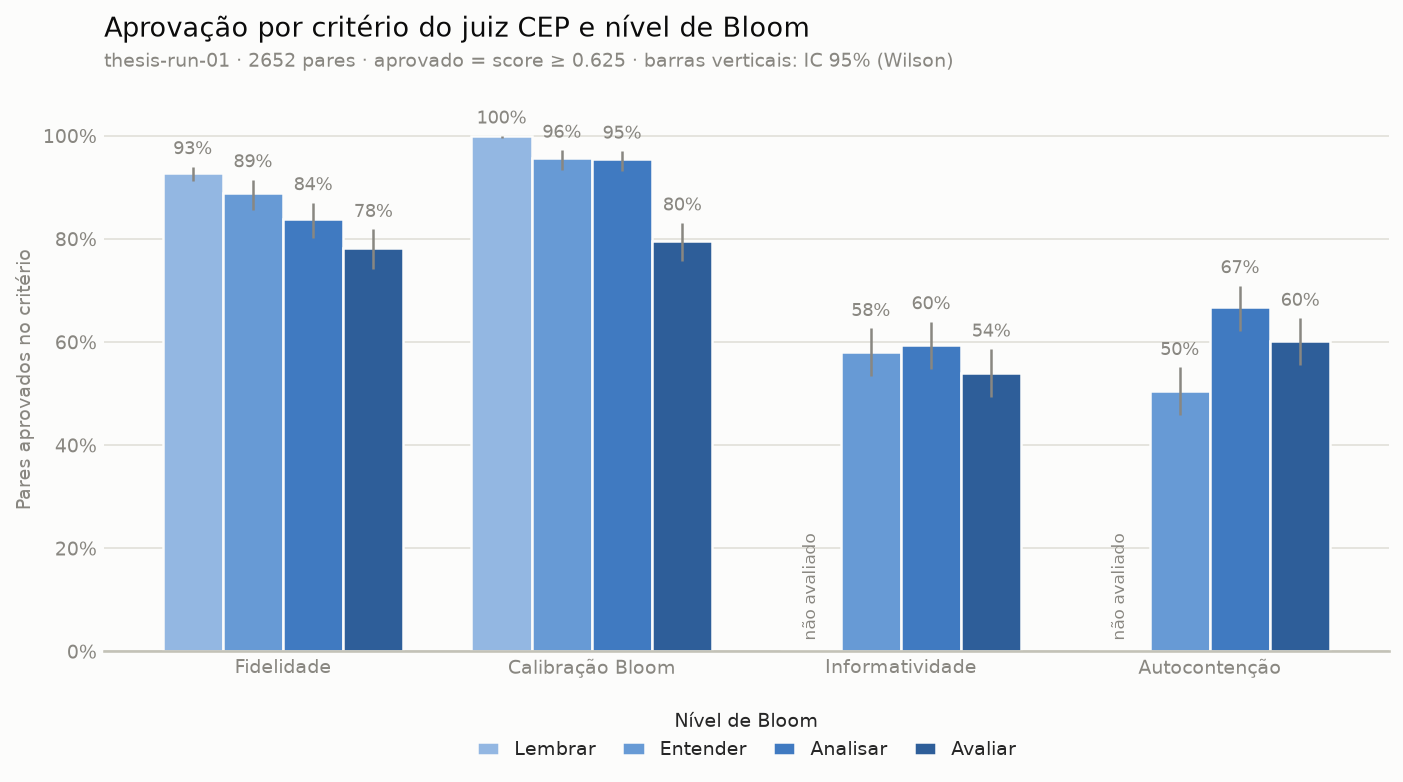

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.ticker import PercentFormatter

# Rampa ordinal de um unico tom: o escurecimento acompanha a ordem de Bloom,
# entao a cor reforca a leitura em vez de depender so da legenda.
BLOOM_RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab"]
INK, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
BAR_WIDTH = 0.78

sns.set_theme(style="white", context="notebook", font_scale=0.95)


def plot_approval(
    rates: pd.DataFrame,
    *,
    ymin: float = 0.0,
    figsize: tuple[float, float] = (9.5, 5.4),
    title: str | None = None,
    subtitle: str | None = None,
    label_size: float = 8.5,
) -> tuple[Figure, Axes]:
    """Desenha a taxa de aprovacao por criterio, agrupada por nivel de Bloom.

    Args:
        rates: Frame no formato de `approval_rates`, indexado por
            (`criterion`, `bloom_level`).
        ymin: Inicio do eixo y. Acima de zero as barras deixam de ser
            proporcionais ao valor: use so quando o rotulo numerico estiver
            visivel em todas as barras.
        figsize: Largura e altura da figura em polegadas.
        title: Titulo do eixo. `None` omite (caso de figura com legenda
            externa, em artigo).
        subtitle: Linha de procedencia sob o titulo. `None` omite.
        label_size: Corpo dos rotulos de valor.

    Returns:
        A figura e o eixo, para o chamador salvar ou ajustar.
    """
    plot_df = rates.reset_index().assign(
        criterio=lambda t: pd.Categorical(
            t["criterion"].map(CRITERION_LABELS),
            [CRITERION_LABELS[c] for c in CRITERIA],
            ordered=True,
        ),
        nivel=lambda t: pd.Categorical(
            t["bloom_level"].map(BLOOM_LABELS),
            [BLOOM_LABELS[b] for b in BLOOM_ORDER],
            ordered=True,
        ),
        # As celulas nao avaliadas viram barra de altura zero (invisivel) apenas
        # para o seaborn reservar a posicao; elas recebem rotulo proprio abaixo.
        altura=lambda t: t["taxa"].fillna(0.0),
    )

    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    fig.patch.set_facecolor(SURFACE)
    ax.set_facecolor(SURFACE)

    sns.barplot(
        data=plot_df,
        x="criterio",
        y="altura",
        hue="nivel",
        palette=BLOOM_RAMP,
        edgecolor=SURFACE,
        linewidth=1.2,
        width=BAR_WIDTH,
        ax=ax,
    )

    top = 1.0 + (1.0 - ymin) * 0.055
    # Um BarContainer por nivel de Bloom, cada um com um patch por criterio, na
    # ordem de `CRITERIA`: da para casar patch e linha da tabela sem adivinhar x.
    for container, level in zip(ax.containers, BLOOM_ORDER):
        for patch, criterion in zip(container.patches, CRITERIA):
            row = rates.loc[(criterion, level)]
            x = patch.get_x() + patch.get_width() / 2
            if pd.isna(row["taxa"]):
                ax.text(
                    x, ymin + (top - ymin) * 0.02, "não avaliado", rotation=90,
                    ha="center", va="bottom", fontsize=label_size - 0.5, color=MUTED,
                )
                continue
            ax.vlines(x, row["ic_lo"], row["ic_hi"], color=MUTED, linewidth=1.2)
            ax.text(
                x, row["ic_hi"] + (top - ymin) * 0.015, f"{row['taxa']:.0%}",
                ha="center", va="bottom", fontsize=label_size, color=MUTED,
            )

    ax.set_ylim(ymin, top)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.set_xlabel("")
    ax.set_ylabel("Pares aprovados no critério", color=MUTED, fontsize=9)
    ax.tick_params(colors=MUTED, labelsize=9, length=0)
    for side, spine in ax.spines.items():
        spine.set_visible(side == "bottom")
        spine.set_color(AXIS)

    if title:
        ax.set_title(title, loc="left", fontsize=13, color=INK, pad=34)
    if subtitle:
        ax.text(0, 1.075, subtitle, transform=ax.transAxes, fontsize=9, color=MUTED)

    ax.legend(
        title="Nível de Bloom", frameon=False, ncol=4, loc="upper center",
        bbox_to_anchor=(0.5, -0.08), fontsize=9, title_fontsize=9,
        columnspacing=1.4, handlelength=1.2,
    )
    sns.despine(ax=ax, left=True)
    fig.tight_layout()
    return fig, ax


fig, ax = plot_approval(
    approval,
    title="Aprovação por critério do juiz CEP e nível de Bloom",
    subtitle=(
        f"{RUN_ID} · {len(df)} pares · aprovado = score ≥ {long['threshold'].max():g}"
        " · barras verticais: IC 95% (Wilson)"
    ),
)
plt.show()

figura salva em notebooks/figures/aprovacao-criterio-bloom-thesis-run-01.pdf (+ .png 300 dpi)


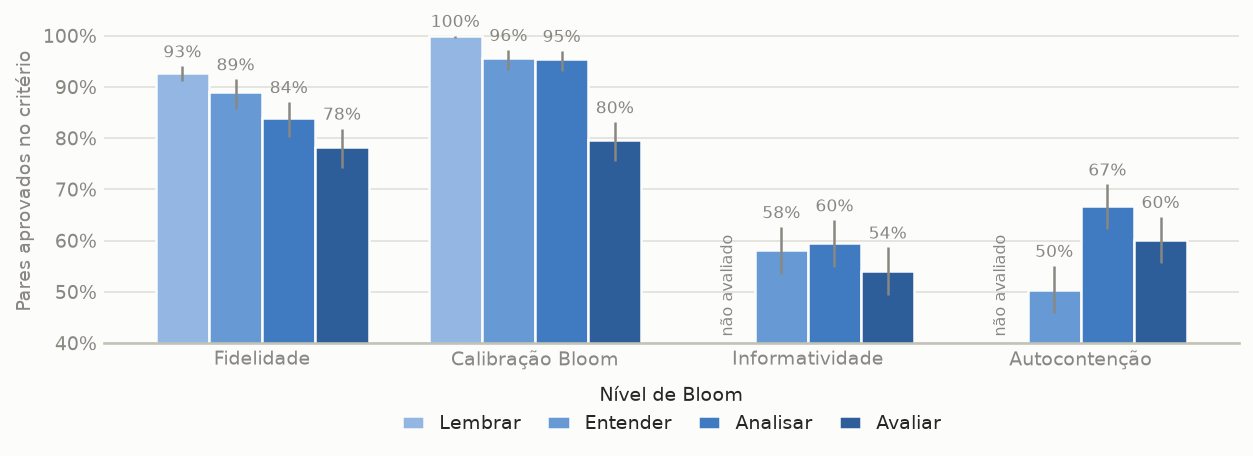

In [7]:
# Versao para artigo: sem titulo/subtitulo (a legenda vai no texto), achatada e
# com eixo iniciando em 40%.
#
# ATENCAO: com `ymin > 0` a altura da barra deixa de ser proporcional a taxa, e
# a diferenca entre barras parece maior do que e. O rotulo numerico em cada
# barra e o que mantem a figura honesta; nao remova. Se o corte do eixo for
# problema na revisao, o grafico de pontos (posicao, nao comprimento) admite
# eixo truncado sem distorcer.
FIG_DIR = REPO_ROOT / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

fig_artigo, ax_artigo = plot_approval(
    approval,
    ymin=0.40,
    figsize=(8.5, 3.2),
    label_size=8.0,
)

fig_path = FIG_DIR / f"aprovacao-criterio-bloom-{RUN_ID}.pdf"
fig_artigo.savefig(fig_path, facecolor=fig_artigo.get_facecolor(), bbox_inches="tight")
fig_artigo.savefig(fig_path.with_suffix(".png"), dpi=300, facecolor=fig_artigo.get_facecolor(), bbox_inches="tight")
print(f"figura salva em {fig_path.relative_to(REPO_ROOT)} (+ .png 300 dpi)")
plt.show()

## Pares aprovados e pares úteis: duas contas diferentes

A figura acima mostra a taxa **marginal** de cada critério. Daqui para frente
duas noções ficam separadas, porque medem coisas diferentes:

- **aprovado**: o par passou em *todos* os critérios avaliados no seu nível.
  É o que o pipeline grava como `is_valid`, e é a conta que dimensiona o funil
  do juiz.
- **útil**: o par é aprovado **e** está em um nível acima de `remember`. É a
  conta que interessa à pesquisa.

O recorte de `remember` não é arbitrário: o próprio juiz não avalia
`informativeness` nem `self_containedness` nesse nível (ver `qa/cep/judge.py`),
e informatividade é exatamente o critério que operacionaliza conhecimento
tácito. Um par `remember` aprovado passou por fidelidade e calibração, nunca
pelo crivo que a pesquisa exige. Chamá-lo de útil importaria uma garantia de
qualidade que nunca foi testada, e a seção de eco de metadados mostra na
prática o que entra por essa porta.

Como as reprovações são pouco correlacionadas entre critérios, a taxa conjunta
fica bem abaixo do pior critério isolado. Duas convenções mantidas aqui:

- critério não avaliado conta como ausência, nunca como reprovação;
- `aprovado` é recomputado a partir dos scores, então divergências em relação
  ao `is_valid` do pipeline ficam visíveis em vez de silenciosas.

In [8]:
# `remember` e recall factual por construcao e o juiz nem aplica
# informatividade nesse nivel, que e o criterio que operacionaliza conhecimento
# tacito. Aprovacao em `remember` mede fidelidade e calibracao, nao utilidade
# para a pesquisa.
NIVEIS_TACITOS = [level for level in BLOOM_ORDER if level != "remember"]


def approved_matrix(pairs: pd.DataFrame) -> pd.DataFrame:
    """Monta a matriz par x criterio com a decisao de aprovacao.

    Args:
        pairs: DataFrame de pares QA produzido por `load_cep_pairs`.

    Returns:
        Frame com uma coluna por criterio de `CRITERIA`: `1.0` aprovado, `0.0`
        reprovado e `NaN` quando o criterio nao foi avaliado (ausencia de
        avaliacao, nunca reprovacao).
    """
    columns: dict[str, pd.Series] = {}
    for criterion in CRITERIA:
        score, threshold = pairs[f"score_{criterion}"], pairs[f"thr_{criterion}"]
        missing = score.isna() | threshold.isna()
        columns[criterion] = (score >= threshold).astype(float).mask(missing)
    return pd.DataFrame(columns, index=pairs.index)


def with_usefulness(pairs: pd.DataFrame) -> pd.DataFrame:
    """Acrescenta as colunas de aprovacao e de utilidade ao frame de pares.

    Distingue duas nocoes:

    - `aprovado`: avaliado em ao menos um criterio e sem reprovacao em nenhum
      dos criterios avaliados; reproduz o `is_valid` do pipeline;
    - `util`: aprovado e em um nivel de `NIVEIS_TACITOS`, isto e, candidato a
      portar conhecimento tacito.

    Args:
        pairs: DataFrame de pares QA produzido por `load_cep_pairs`.

    Returns:
        Copia de `pairs` com `n_avaliados`, `n_reprovados`, `aprovado`,
        `candidato` e `util`.
    """
    approved = approved_matrix(pairs)
    out = pairs.copy()
    out["n_avaliados"] = approved.notna().sum(axis=1)
    out["n_reprovados"] = approved.eq(0.0).sum(axis=1)
    out["aprovado"] = (out["n_reprovados"] == 0) & (out["n_avaliados"] > 0)
    out["candidato"] = out["bloom_level"].isin(NIVEIS_TACITOS)
    out["util"] = out["aprovado"] & out["candidato"]
    return out


def joint_rates(pairs: pd.DataFrame) -> pd.DataFrame:
    """Agrega a taxa conjunta de aprovacao por nivel de Bloom.

    Mede o funil do juiz, entao usa `aprovado` (todos os criterios avaliados) e
    nao `util`: em `remember` a taxa continua definida.

    Args:
        pairs: Frame com a coluna `aprovado`, de `with_usefulness`.

    Returns:
        Frame indexado por `bloom_level` (na ordem de `BLOOM_ORDER`) com
        `pares`, `aprovados`, `taxa` e o IC 95% de Wilson (`ic_lo`, `ic_hi`).
    """
    rates = pairs.groupby("bloom_level", observed=True)["aprovado"].agg(
        pares="size", aprovados="sum"
    )
    rates["taxa"] = rates["aprovados"] / rates["pares"]
    rates[["ic_lo", "ic_hi"]] = [
        wilson_interval(int(k), int(n)) for k, n in zip(rates["aprovados"], rates["pares"])
    ]
    return rates.reindex(BLOOM_ORDER)


pairs = with_usefulness(df)
approved = approved_matrix(pairs)
joint = joint_rates(pairs)
display(joint)

print(f"aprovados (todos os criterios avaliados): {int(pairs['aprovado'].sum())}"
      f" / {len(pairs)} = {pairs['aprovado'].mean():.1%}")
print(f"is_valid do pipeline: {int(pairs['is_valid'].sum())} ({pairs['is_valid'].mean():.1%})")
print(f"divergencia aprovado vs is_valid: {int((pairs['aprovado'] != pairs['is_valid']).sum())} pares")

candidatos = int(pairs["candidato"].sum())
uteis = int(pairs["util"].sum())
print(f"\npares uteis (aprovados acima de remember): {uteis} / {candidatos} candidatos"
      f" = {uteis / candidatos:.1%}, ou {uteis / len(pairs):.1%} dos {len(pairs)} pares gerados")

# A divergencia e o par sem score de faithfulness: o juiz nao devolveu nota e o
# pipeline contou como reprovacao. Nao e reprovacao, e falha de avaliacao.
sem_nota = pairs[pairs["score_faithfulness"].isna()]
print(f"\npares sem score de faithfulness (falha do juiz): {len(sem_nota)}")
display(
    sem_nota.groupby(["bloom_level", "rejected_at"], observed=True)
    .size()
    .to_frame("pares")
)

,pares,aprovados,taxa,ic_lo,ic_hi
bloom_level,,,,,
remember,1326,1231,0.928356,0.913202,0.941035
understand,442,115,0.260181,0.221470,0.303025
analyze,442,146,0.330317,0.288096,0.375461
evaluate,442,93,0.210407,0.174985,0.250820


aprovados (todos os criterios avaliados): 1585 / 2652 = 59.8%
is_valid do pipeline: 1573 (59.3%)
divergencia aprovado vs is_valid: 12 pares

pares uteis (aprovados acima de remember): 354 / 1326 candidatos = 26.7%, ou 13.3% dos 2652 pares gerados

pares sem score de faithfulness (falha do juiz): 12


,,pares
bloom_level,rejected_at,
remember,cep_validation,12


In [9]:
# Quanto do funil cada critério sustenta, e quanto ele custa em pares.
def unique_blockers(pairs: pd.DataFrame, approved: pd.DataFrame) -> pd.DataFrame:
    """Conta, por nivel de Bloom, os pares reprovados em um unico criterio.

    E o ganho direto de pares uteis caso aquele criterio saisse do filtro: os
    demais criterios do par ja passaram.

    Args:
        pairs: Frame com `bloom_level` e `aprovado`.
        approved: Matriz de aprovacao de `approved_matrix`.

    Returns:
        Frame nivel x criterio com a contagem de gargalos unicos, mais a
        coluna `reprovados` (total de pares nao uteis do nivel).
    """
    counts: dict[str, pd.Series] = {}
    for criterion in CRITERIA:
        others = [c for c in CRITERIA if c != criterion]
        only = approved[criterion].eq(0.0) & approved[others].fillna(1.0).eq(1.0).all(axis=1)
        counts[criterion] = only.groupby(pairs["bloom_level"], observed=True).sum()
    table = pd.DataFrame(counts).reindex(BLOOM_ORDER).astype(int)
    table["reprovados"] = (
        (~pairs["aprovado"]).groupby(pairs["bloom_level"], observed=True).sum().reindex(BLOOM_ORDER)
    )
    return table


def drop_one_scenarios(pairs: pd.DataFrame, approved: pd.DataFrame) -> pd.DataFrame:
    """Pares uteis por nivel sob cenarios de remocao de um criterio.

    Args:
        pairs: Frame com `bloom_level`.
        approved: Matriz de aprovacao de `approved_matrix`.

    Returns:
        Frame nivel x cenario com a contagem de pares uteis e a linha `TOTAL`.
    """

    def yield_for(columns: list[str]) -> pd.Series:
        ok = approved[columns].fillna(1.0).eq(1.0).all(axis=1)
        grouped = ok.groupby(pairs["bloom_level"], observed=True).sum()
        return grouped.reindex(BLOOM_ORDER).astype(int)

    scenarios: dict[str, list[str]] = {"atual (4 criterios)": CRITERIA}
    for criterion in CRITERIA:
        label = CRITERION_LABELS[criterion].lower()
        scenarios[f"sem {label}"] = [c for c in CRITERIA if c != criterion]

    table = pd.DataFrame({name: yield_for(cols) for name, cols in scenarios.items()})
    table.loc["TOTAL"] = table.sum()
    return table


print("gargalo unico (pares reprovados so nesse criterio)")
display(unique_blockers(pairs, approved))

print("cenarios de remocao de criterio (pares uteis)")
cenarios = drop_one_scenarios(pairs, approved)
display(cenarios)
display((cenarios.loc["TOTAL"] / len(pairs)).to_frame("fracao_do_corpus").T.round(3))

gargalo unico (pares reprovados so nesse criterio)


,faithfulness,bloom_calibration,informativeness,self_containedness,reprovados
bloom_level,,,,,
remember,94,0,0,0,95
understand,10,2,80,114,327
analyze,27,12,91,67,296
evaluate,22,19,75,61,349


cenarios de remocao de criterio (pares uteis)


,atual (4 criterios),sem fidelidade,sem calibração bloom,sem informatividade,sem autocontenção
bloom_level,,,,,
remember,1231,1325,1231,1231,1231
understand,115,125,117,195,229
analyze,146,173,158,237,213
evaluate,93,115,112,168,154
TOTAL,1585,1738,1618,1831,1827


,atual (4 criterios),sem fidelidade,sem calibração bloom,sem informatividade,sem autocontenção
fracao_do_corpus,0.598,0.655,0.61,0.69,0.689


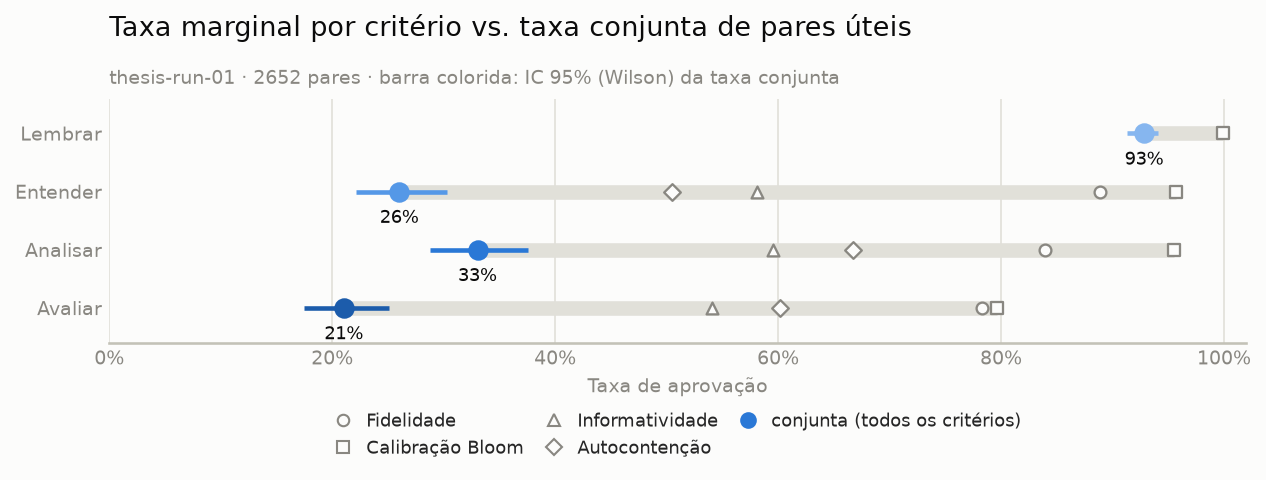

In [10]:
from matplotlib.lines import Line2D

# Marcadores abertos = taxa marginal de cada criterio; ponto cheio = taxa
# conjunta. A barra cinza liga os dois extremos, entao o vao entre "pior
# criterio" e "par utilizavel" e a propria leitura do grafico.
CRITERION_MARKERS = {
    "faithfulness": "o",
    "bloom_calibration": "s",
    "informativeness": "^",
    "self_containedness": "D",
}


def plot_marginal_vs_joint(
    marginal: pd.DataFrame,
    joint: pd.DataFrame,
    *,
    figsize: tuple[float, float] = (8.6, 3.6),
    title: str | None = None,
    subtitle: str | None = None,
) -> tuple[Figure, Axes]:
    """Contrasta as taxas marginais por criterio com a taxa conjunta.

    Args:
        marginal: Frame de `approval_rates`, indexado por
            (`criterion`, `bloom_level`).
        joint: Frame de `joint_rates`, indexado por `bloom_level`.
        figsize: Largura e altura da figura em polegadas.
        title: Titulo do eixo. `None` omite.
        subtitle: Linha de procedencia sob o titulo. `None` omite.

    Returns:
        A figura e o eixo, para o chamador salvar ou ajustar.
    """
    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    fig.patch.set_facecolor(SURFACE)
    ax.set_facecolor(SURFACE)

    for index, level in enumerate(BLOOM_ORDER):
        y = len(BLOOM_ORDER) - 1 - index
        taxa_conjunta = joint.loc[level, "taxa"]
        marginais = [
            marginal.loc[(criterion, level), "taxa"]
            for criterion in CRITERIA
            if pd.notna(marginal.loc[(criterion, level), "taxa"])
        ]
        extremos = [*marginais, taxa_conjunta]
        ax.hlines(y, min(extremos), max(extremos), color=GRID, linewidth=7, zorder=1)

        for criterion in CRITERIA:
            taxa = marginal.loc[(criterion, level), "taxa"]
            if pd.isna(taxa):
                continue
            ax.scatter(
                taxa, y, marker=CRITERION_MARKERS[criterion], s=32, facecolor=SURFACE,
                edgecolor=MUTED, linewidth=1.1, zorder=2,
            )

        ax.scatter(taxa_conjunta, y, s=78, color=BLOOM_RAMP[index], zorder=3)
        ax.annotate(
            f"{taxa_conjunta:.0%}", (taxa_conjunta, y), textcoords="offset points",
            xytext=(0, -15), ha="center", fontsize=8.5, color=INK,
        )
        ax.hlines(
            y, joint.loc[level, "ic_lo"], joint.loc[level, "ic_hi"],
            color=BLOOM_RAMP[index], linewidth=2.2, zorder=4,
        )

    ax.set_yticks(range(len(BLOOM_ORDER)))
    ax.set_yticklabels([BLOOM_LABELS[b] for b in reversed(BLOOM_ORDER)])
    ax.set_ylim(-0.6, len(BLOOM_ORDER) - 0.4)
    ax.set_xlim(0, 1.02)
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.xaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.set_xlabel("Taxa de aprovação", color=MUTED, fontsize=9)
    ax.tick_params(colors=MUTED, labelsize=9, length=0)
    for side, spine in ax.spines.items():
        spine.set_visible(side == "bottom")
        spine.set_color(AXIS)

    if title:
        ax.set_title(title, loc="left", fontsize=13, color=INK, pad=30)
    if subtitle:
        ax.text(0, 1.06, subtitle, transform=ax.transAxes, fontsize=9, color=MUTED)

    handles = [
        Line2D(
            [], [], marker=CRITERION_MARKERS[c], linestyle="none", markersize=5.5,
            markerfacecolor=SURFACE, markeredgecolor=MUTED, label=CRITERION_LABELS[c],
        )
        for c in CRITERIA
    ]
    handles.append(
        Line2D([], [], marker="o", linestyle="none", markersize=7, color=BLOOM_RAMP[2],
               label="conjunta (todos os critérios)")
    )
    ax.legend(
        handles=handles, frameon=False, ncol=3, loc="upper center",
        bbox_to_anchor=(0.5, -0.22), fontsize=8.5, columnspacing=1.2, handlelength=1.0,
    )
    sns.despine(ax=ax, left=True)
    fig.tight_layout()
    return fig, ax


fig_conjunta, _ = plot_marginal_vs_joint(
    approval,
    joint,
    title="Taxa marginal por critério vs. taxa conjunta de pares úteis",
    subtitle=f"{RUN_ID} · {len(pairs)} pares · barra colorida: IC 95% (Wilson) da taxa conjunta",
)
plt.show()

## Decomposição aditiva: o que decidiu o destino de cada par

A figura de aprovação por critério é **marginal**: cada célula é calculada de
forma independente, sobre todos os pares com nota naquele critério. Ela não
mistura critérios (um par reprovado em informatividade continua contando como
aprovado em calibração, e o juiz avalia os quatro critérios de todo par, sem
curto-circuito), mas ela também não diz qual critério *decidiu* a reprovação.

A diferença é grande para `bloom_calibration`: ela reprova 130 pares no run,
e é a única razão da reprovação em apenas 33. Nos outros 97 o par já estava
reprovado por informatividade ou autocontenção. Ler a barra de calibração como
"pares que a calibração derrubou" superestima o filtro em quase 4x, a maior
distorção dos quatro critérios (fidelidade 2,0x, informatividade 2,3x,
autocontenção 2,2x).

A decomposição abaixo atribui cada par a **um único** segmento, então as
colunas somam exatamente aos pares gerados no nível:

- `aprovado`: passou em todos os critérios aplicáveis ao nível;
- `só <critério>`: reprovou naquele critério e passou em todos os outros, ou
  seja, aquele critério foi o fator decisivo;
- `2 ou mais critérios`: reprovou em mais de um, nenhum foi decisivo isolado;
- `sem avaliação (falha do juiz)`: o juiz não devolveu nota de um critério
  aplicável, e o pipeline contou como reprovação. Não é reprovação, é ausência
  de avaliação, e é o que separa os 1585 pares aprovados dos 1573 `is_valid`.

Os critérios aplicáveis a cada nível são inferidos dos próprios artefatos (um
critério é aplicável se há ao menos uma nota dele no nível), e não codificados
aqui, para a figura acompanhar mudanças na configuração do juiz.

Esta figura é sobre **aprovação**, não sobre utilidade: o segmento `aprovado` de
`remember` são 1219 pares que passaram por fidelidade e calibração e nunca por
informatividade. Eles fecham o `is_valid` do pipeline, e é por isso que
aparecem aqui, mas não contam como pares úteis.

In [11]:
SEGMENT_ORDER = ["aprovado", *CRITERIA, "multi", "sem_avaliacao"]
SEGMENT_LABELS = {
    "aprovado": "aprovado",
    "faithfulness": f"só {CRITERION_LABELS['faithfulness']}",
    "bloom_calibration": f"só {CRITERION_LABELS['bloom_calibration']}",
    "informativeness": f"só {CRITERION_LABELS['informativeness']}",
    "self_containedness": f"só {CRITERION_LABELS['self_containedness']}",
    "multi": "2 ou mais critérios",
    "sem_avaliacao": "sem avaliação (falha do juiz)",
}


def applicable_criteria(pairs: pd.DataFrame) -> dict[str, list[str]]:
    """Descobre, por nivel de Bloom, quais criterios o juiz de fato avaliou.

    Lido dos artefatos em vez de codificado: se a configuracao do juiz mudar
    (hoje `informativeness` e `self_containedness` nao se aplicam a
    `remember`), a decomposicao acompanha.

    Args:
        pairs: DataFrame de pares QA com as colunas `score_*`.

    Returns:
        Mapa de nivel de Bloom para a lista de criterios com ao menos uma nota.
    """
    mapa: dict[str, list[str]] = {}
    for level in BLOOM_ORDER:
        nivel = pairs[pairs["bloom_level"] == level]
        mapa[level] = [c for c in CRITERIA if nivel[f"score_{c}"].notna().any()]
    return mapa


def rejection_reason(
    pairs: pd.DataFrame,
    approved: pd.DataFrame,
    aplicaveis: dict[str, list[str]],
) -> pd.Series:
    """Atribui a cada par o unico motivo que decidiu seu destino.

    Um par reprovado em exatamente um criterio recebe o nome desse criterio: e
    o fator decisivo, porque passou em todos os outros. Reprovado em mais de um
    vira `multi`, e nenhum criterio pode ser responsabilizado isoladamente.

    Args:
        pairs: DataFrame de pares QA com `bloom_level`.
        approved: Matriz de aprovacao de `approved_matrix`.
        aplicaveis: Mapa de `applicable_criteria`.

    Returns:
        Serie com um rotulo de `SEGMENT_ORDER` por par.
    """
    motivo = pd.Series(index=pairs.index, dtype="object", name="motivo")
    for level, esperados in aplicaveis.items():
        no_nivel = pairs["bloom_level"] == level
        bloco = approved.loc[no_nivel, esperados]
        falhas = bloco.eq(0.0)
        n_falhas = falhas.sum(axis=1)

        rotulo = pd.Series("aprovado", index=bloco.index)
        rotulo[(n_falhas == 0) & bloco.isna().any(axis=1)] = "sem_avaliacao"
        uma_falha = n_falhas == 1
        rotulo[uma_falha] = falhas.loc[uma_falha].idxmax(axis=1)
        rotulo[n_falhas > 1] = "multi"
        motivo[no_nivel] = rotulo
    return motivo


def rejection_decomposition(pairs: pd.DataFrame) -> pd.DataFrame:
    """Tabula os motivos por nivel de Bloom, na ordem de `SEGMENT_ORDER`.

    Args:
        pairs: DataFrame com `bloom_level` e `motivo`.

    Returns:
        Frame nivel x segmento com contagens; as linhas somam aos pares
        gerados no nivel.
    """
    table = pd.crosstab(pairs["bloom_level"], pairs["motivo"])
    table = table.reindex(index=BLOOM_ORDER, columns=SEGMENT_ORDER, fill_value=0)
    return table.rename(columns=SEGMENT_LABELS)


pairs["motivo"] = rejection_reason(pairs, approved, applicable_criteria(pairs))
decomposicao = rejection_decomposition(pairs)
decomposicao["total"] = decomposicao.sum(axis=1)
display(decomposicao)

print("em % dos pares gerados no nivel")
share = decomposicao.drop(columns="total")
display((share.div(decomposicao["total"], axis=0) * 100).round(1))

# A decomposicao e fechada: o segmento `aprovado` tem que reproduzir o
# is_valid do pipeline, e cada linha somar aos pares gerados no nivel.
aprovados = int(decomposicao["aprovado"].sum())
print(f"\naprovados na decomposicao: {aprovados} | is_valid do pipeline: {int(pairs['is_valid'].sum())}")
print(f"soma dos segmentos: {int(share.to_numpy().sum())} | pares: {len(pairs)}")

motivo,aprovado,só Fidelidade,só Calibração Bloom,só Informatividade,só Autocontenção,2 ou mais critérios,sem avaliação (falha do juiz),total
bloom_level,,,,,,,,
remember,1219,94,0,0,0,1,12,1326
understand,115,10,2,80,114,121,0,442
analyze,146,27,12,91,67,99,0,442
evaluate,93,22,19,75,61,172,0,442


em % dos pares gerados no nivel


motivo,aprovado,só Fidelidade,só Calibração Bloom,só Informatividade,só Autocontenção,2 ou mais critérios,sem avaliação (falha do juiz)
bloom_level,,,,,,,
remember,91.9,7.1,0.0,0.0,0.0,0.1,0.9
understand,26.0,2.3,0.5,18.1,25.8,27.4,0.0
analyze,33.0,6.1,2.7,20.6,15.2,22.4,0.0
evaluate,21.0,5.0,4.3,17.0,13.8,38.9,0.0



aprovados na decomposicao: 1573 | is_valid do pipeline: 1573
soma dos segmentos: 2652 | pares: 2652


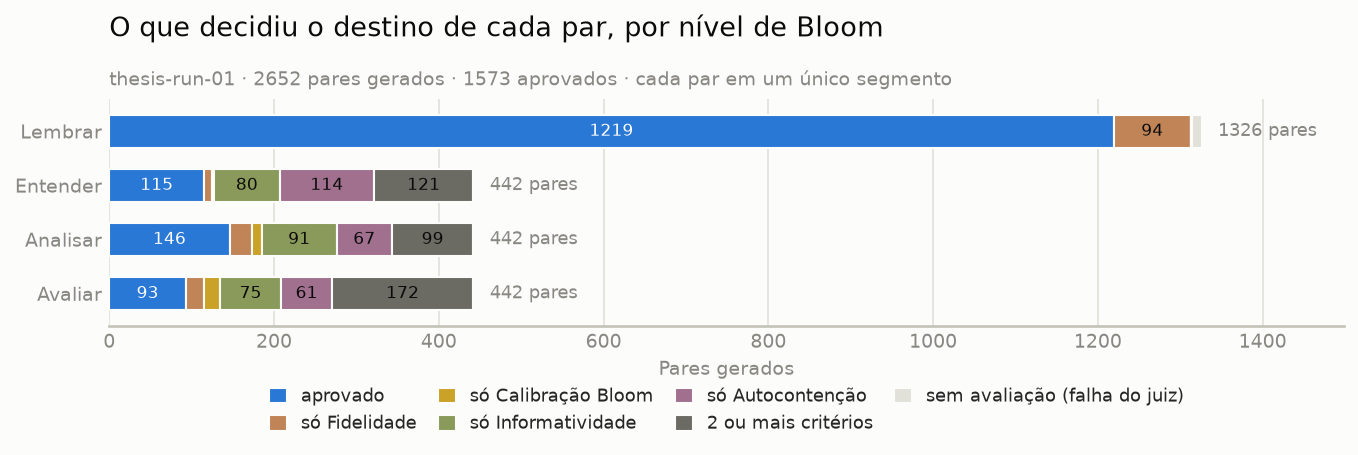

In [12]:
# Azul para o aprovado (mesma familia da rampa de Bloom) e tons quentes para os
# motivos de reprovacao: a distincao aprovado/reprovado sobrevive em escala de
# cinza, e cada motivo tem matiz propria em vez de depender da ordem da pilha.
SEGMENT_COLORS = {
    "aprovado": BLOOM_RAMP[2],
    "faithfulness": "#c08457",
    "bloom_calibration": "#c9a227",
    "informativeness": "#8a9a5b",
    "self_containedness": "#a2708f",
    "multi": "#6b6a63",
    "sem_avaliacao": GRID,
}


def plot_rejection_decomposition(
    decomposicao: pd.DataFrame,
    *,
    figsize: tuple[float, float] = (9.2, 3.4),
    title: str | None = None,
    subtitle: str | None = None,
    normalize: bool = False,
    min_share: float = 0.028,
) -> tuple[Figure, Axes]:
    """Desenha a decomposicao aditiva dos pares gerados, por nivel de Bloom.

    Barras empilhadas, cada par em um unico segmento. Em contagem absoluta o
    comprimento total e o numero de pares gerados no nivel (3 `remember` por
    chunk contra 1 dos demais), o que espreme os niveis superiores; normalizado,
    os quatro niveis ficam comparaveis e o total vai para a anotacao a direita.
    Os rotulos internos sao sempre a contagem, nos dois modos.

    Args:
        decomposicao: Frame de `rejection_decomposition`, com ou sem a coluna
            `total` (ignorada).
        figsize: Largura e altura da figura em polegadas.
        title: Titulo do eixo. `None` omite (caso de figura para artigo).
        subtitle: Linha de procedencia sob o titulo. `None` omite.
        normalize: Se `True`, cada barra vira 1,0 e o eixo passa a proporcao.
        min_share: Largura minima do segmento, como fracao da extensao do eixo,
            para receber rotulo interno; os menores ficam legiveis so na tabela.

    Returns:
        A figura e o eixo, para o chamador salvar ou ajustar.
    """
    contagens = decomposicao.drop(columns="total", errors="ignore")
    totais = contagens.sum(axis=1)
    dados = contagens.div(totais, axis=0) if normalize else contagens
    limite = 1.0 if normalize else float(totais.max())
    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    fig.patch.set_facecolor(SURFACE)
    ax.set_facecolor(SURFACE)

    posicoes = [len(BLOOM_ORDER) - 1 - i for i in range(len(BLOOM_ORDER))]
    esquerda = pd.Series(0.0, index=dados.index)
    for chave in SEGMENT_ORDER:
        coluna = SEGMENT_LABELS[chave]
        valores = dados[coluna]
        ax.barh(
            posicoes, valores, left=esquerda, height=0.62,
            color=SEGMENT_COLORS[chave], edgecolor=SURFACE, linewidth=1.0,
            label=coluna, zorder=2,
        )
        for y, base, valor, contagem in zip(posicoes, esquerda, valores, contagens[coluna]):
            if valor / limite >= min_share:
                ax.text(
                    base + valor / 2, y, f"{int(contagem)}", ha="center", va="center",
                    fontsize=8, color=SURFACE if chave == "aprovado" else INK, zorder=3,
                )
        esquerda = esquerda + valores

    for y, fim, total in zip(posicoes, esquerda, totais):
        rotulo = f"n = {int(total)}" if normalize else f"{int(total)} pares"
        ax.text(fim + limite * 0.015, y, rotulo, va="center", fontsize=8.5, color=MUTED)

    ax.set_yticks(posicoes)
    ax.set_yticklabels([BLOOM_LABELS[b] for b in BLOOM_ORDER])
    ax.set_ylim(-0.6, len(BLOOM_ORDER) - 0.4)
    ax.set_xlim(0, limite * 1.13)
    ax.xaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    if normalize:
        ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.set_xlabel(
        "Proporção dos pares gerados" if normalize else "Pares gerados",
        color=MUTED, fontsize=9,
    )
    ax.tick_params(colors=MUTED, labelsize=9, length=0)
    for side, spine in ax.spines.items():
        spine.set_visible(side == "bottom")
        spine.set_color(AXIS)

    if title:
        ax.set_title(title, loc="left", fontsize=13, color=INK, pad=30)
    if subtitle:
        ax.text(0, 1.06, subtitle, transform=ax.transAxes, fontsize=9, color=MUTED)

    ax.legend(
        frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.2),
        fontsize=8.5, columnspacing=1.2, handlelength=1.0, handleheight=1.0,
    )
    sns.despine(ax=ax, left=True)
    fig.tight_layout()
    return fig, ax


fig_decomposicao, _ = plot_rejection_decomposition(
    decomposicao,
    title="O que decidiu o destino de cada par, por nível de Bloom",
    subtitle=(
        f"{RUN_ID} · {len(pairs)} pares gerados · {int(pairs['is_valid'].sum())} aprovados"
        " · cada par em um único segmento"
    ),
)
plt.show()

## Rendimento por chunk: tamanho, taxa e densidade

O gerador produz uma escada de Bloom fixa por chunk (`bloom_distribution`
travado em 3/1/1/1), independente do tamanho do chunk. Dos 6 pares, 3 são
candidatos a par útil (os níveis acima de `remember`), também sem relação com
o tamanho. Isso separa duas perguntas:

- **taxa de aproveitamento**: dos 3 candidatos do chunk, quantos são úteis;
- **densidade**: quantos pares úteis o chunk rende por caractere de contexto.

Com orçamento fixo, o número de *candidatos* por caractere é inversamente
proporcional ao tamanho por construção. A densidade de pares *úteis* não
herda isso de forma limpa, porque a taxa de aproveitamento se move na direção
oposta: chunk curto gera candidatos baratos que reprovam. O efeito líquido é o
que decide se documentos longas estão sendo exploradas na mesma proporção
que as curtas.

In [13]:
# Faixas de tamanho de chunk: a janela do chunker termina em 4000 caracteres,
# e as faixas finas no topo separam chunks "cheios" dos parciais.
CHUNK_BINS = [0, 500, 1000, 2000, 3000, 3500, 3900, 4001]
CHUNK_LABELS = ["<0,5k", "0,5-1k", "1-2k", "2-3k", "3-3,5k", "3,5-3,9k", "3,9-4k"]


def chunk_table(pairs: pd.DataFrame) -> pd.DataFrame:
    """Agrega os pares por chunk, com tamanho do contexto e pares uteis.

    Args:
        pairs: Frame com `chunk_id`, `context_chars`, `candidato` e `util`.

    Returns:
        Frame indexado por `chunk_id` com `source_gdrive_id`, `chars`,
        `gerados`, `candidatos`, `uteis`, `taxa` (sobre os candidatos) e a
        `faixa` de tamanho.

    Raises:
        ValueError: Se `context_chars` variar dentro de um mesmo `chunk_id`,
            o que invalidaria `chars` como tamanho do chunk.
    """
    if (pairs.groupby("chunk_id", observed=True)["context_chars"].nunique() > 1).any():
        raise ValueError("context_chars varia dentro de um chunk_id")

    table = pairs.groupby("chunk_id", observed=True).agg(
        source_gdrive_id=("source_gdrive_id", "first"),
        chars=("context_chars", "max"),
        gerados=("util", "size"),
        candidatos=("candidato", "sum"),
        uteis=("util", "sum"),
    )
    table["taxa"] = table["uteis"] / table["candidatos"]
    table["faixa"] = pd.cut(table["chars"], CHUNK_BINS, labels=CHUNK_LABELS, right=False)
    return table


chunks = chunk_table(pairs)
print(f"{len(chunks)} chunks · {int(chunks['gerados'].sum())} pares gerados"
      f" · {int(chunks['candidatos'].sum())} candidatos acima de remember")
display(chunks["chars"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_frame("chars"))

distribuicao = (
    chunks["uteis"].value_counts().reindex(range(4), fill_value=0).sort_index().to_frame("chunks")
)
distribuicao["fracao"] = distribuicao["chunks"] / len(chunks)
distribuicao.index.name = "uteis"
print("pares uteis por chunk (de 3 candidatos)")
display(distribuicao)

print(f"chunks sem nenhum par util: {int((chunks['uteis'] == 0).sum())} de {len(chunks)}")
print(f"chunks com os 3 candidatos uteis: {int((chunks['uteis'] == 3).sum())}")
print(f"media de pares uteis por chunk: {chunks['uteis'].mean():.2f} de 3")

# Para referencia, quantos pares aprovados cada chunk rende em cada nivel: em
# `remember` a base factual passa quase sempre, e e ela que sustenta o total do
# pipeline sem contribuir com pares uteis.
aprovados_por_nivel = (
    pairs.pivot_table(
        index="chunk_id", columns="bloom_level", values="aprovado", aggfunc="sum", observed=True
    )
    .reindex(columns=BLOOM_ORDER)
    .fillna(0)
    .astype(int)
)
display(aprovados_por_nivel.apply(lambda column: column.value_counts()).fillna(0).astype(int))

442 chunks · 2652 pares gerados · 1326 candidatos acima de remember


,chars
count,442.000000
mean,2797.513575
std,1284.869709
min,137.000000
5%,414.450000
25%,1660.250000
50%,3424.500000
75%,3931.500000
95%,3991.000000
max,4000.000000


pares uteis por chunk (de 3 candidatos)


,chunks,fracao
uteis,,
0,200,0.452489
1,151,0.341629
2,70,0.158371
3,21,0.047511


chunks sem nenhum par util: 200 de 442
chunks com os 3 candidatos uteis: 21
media de pares uteis por chunk: 0.80 de 3


bloom_level,remember,understand,analyze,evaluate
0,3,327,296,349
1,5,115,146,93
2,76,0,0,0
3,358,0,0,0


In [14]:
def band_yield(chunks: pd.DataFrame) -> pd.DataFrame:
    """Taxa e densidade de pares uteis por faixa de tamanho de chunk.

    Args:
        chunks: Frame de `chunk_table`.

    Returns:
        Frame indexado por `faixa` com `chunks`, `chars`, `candidatos`,
        `uteis`, `taxa` (sobre os candidatos) e IC 95% de Wilson,
        `uteis_por_1k` (pares uteis por mil caracteres de contexto) e
        `chars_por_util`.
    """
    table = chunks.groupby("faixa", observed=True).agg(
        chunks=("uteis", "size"),
        chars=("chars", "sum"),
        candidatos=("candidatos", "sum"),
        uteis=("uteis", "sum"),
    )
    table["taxa"] = table["uteis"] / table["candidatos"]
    table[["ic_lo", "ic_hi"]] = [
        wilson_interval(int(k), int(n)) for k, n in zip(table["uteis"], table["candidatos"])
    ]
    table["uteis_por_1k"] = table["uteis"] / table["chars"] * 1000
    table["chars_por_util"] = table["chars"] / table["uteis"]
    return table


def spearman(left: pd.Series, right: pd.Series) -> float:
    """Correlacao de Spearman como Pearson sobre os postos.

    Calculada assim para nao exigir `scipy`, que nao esta no extra `analysis`.

    Args:
        left: Primeira serie.
        right: Segunda serie, alinhada por indice.

    Returns:
        Coeficiente entre -1 e 1.
    """
    return float(left.rank().corr(right.rank()))


def short_vs_long(pairs: pd.DataFrame, cutoff: int = 1000) -> pd.DataFrame:
    """Compara a taxa de aprovacao em chunks curtos e longos, por nivel.

    Usa `aprovado` para a taxa continuar definida em `remember`, que serve de
    controle: se o encurtamento do chunk derruba os niveis superiores e nao o
    recall factual, o efeito e sobre o raciocinio, nao sobre a extracao.

    Args:
        pairs: Frame com `context_chars`, `bloom_level` e `aprovado`.
        cutoff: Fronteira em caracteres entre chunk curto e longo.

    Returns:
        Frame indexado por (`bloom_level`, `faixa`) com `pares`, `aprovados`,
        `taxa` e o IC 95% de Wilson.
    """
    curto = pairs["context_chars"] < cutoff
    faixa = pd.Series(
        pd.Categorical(
            curto.map({True: f"<{cutoff}", False: f">={cutoff}"}),
            [f"<{cutoff}", f">={cutoff}"],
            ordered=True,
        ),
        index=pairs.index,
        name="faixa",
    )
    grouped = pairs.groupby([pairs["bloom_level"], faixa], observed=True)["aprovado"]
    table = grouped.agg(pares="size", aprovados="sum")
    table["taxa"] = table["aprovados"] / table["pares"]
    table[["ic_lo", "ic_hi"]] = [
        wilson_interval(int(k), int(n)) for k, n in zip(table["aprovados"], table["pares"])
    ]
    return table.reindex(BLOOM_ORDER, level="bloom_level")


faixas = band_yield(chunks)
print("taxa e densidade por faixa de tamanho de chunk")
display(faixas)

print("chunk curto vs. longo: taxa de aprovacao por nivel de Bloom")
display(short_vs_long(pairs))

print(f"Spearman tamanho do chunk x taxa de uteis do chunk: {spearman(chunks['chars'], chunks['taxa']):+.3f}")
for level in BLOOM_ORDER:
    nivel = pairs[pairs["bloom_level"] == level]
    agg = nivel.groupby("chunk_id", observed=True).agg(
        chars=("context_chars", "max"), taxa=("aprovado", "mean")
    )
    print(f"  {level:11s} (aprovacao) {spearman(agg['chars'], agg['taxa']):+.3f}")

taxa e densidade por faixa de tamanho de chunk


,chunks,chars,candidatos,uteis,taxa,ic_lo,ic_hi,uteis_por_1k,chars_por_util
faixa,,,,,,,,,
"<0,5k",27,8113,81,7,0.086420,0.042492,0.167801,0.862813,1159.000000
"0,5-1k",35,24598,105,20,0.190476,0.126824,0.275978,0.813074,1229.900000
1-2k,75,111845,225,60,0.266667,0.213154,0.328013,0.536457,1864.083333
2-3k,51,130967,153,43,0.281046,0.215855,0.356963,0.328327,3045.744186
"3-3,5k",39,128356,117,39,0.333333,0.254414,0.422849,0.303842,3291.179487
"3,5-3,9k",87,324958,261,81,0.310345,0.257309,0.368882,0.249263,4011.827160
"3,9-4k",128,507664,384,104,0.270833,0.228817,0.317389,0.204860,4881.384615


chunk curto vs. longo: taxa de aprovacao por nivel de Bloom


pares  aprovados      taxa     ic_lo     ic_hi
bloom_level faixa                                                 
remember    <1000     186        177  0.951613  0.910611  0.974338
            >=1000   1140       1054  0.924561  0.907764  0.938507
understand  <1000      62         12  0.193548  0.114337  0.308520
            >=1000    380        103  0.271053  0.228816  0.317872
analyze     <1000      62          8  0.129032  0.066858  0.234496
            >=1000    380        138  0.363158  0.316397  0.412658
evaluate    <1000      62          7  0.112903  0.055778  0.215200
            >=1000    380         86  0.226316  0.187103  0.271006

Spearman tamanho do chunk x taxa de uteis do chunk: +0.112
  remember    (aprovacao) -0.086
  understand  (aprovacao) +0.037
  analyze     (aprovacao) +0.103
  evaluate    (aprovacao) +0.077


In [15]:
def per_document_yield(chunks: pd.DataFrame, quantis: int = 5) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Rendimento por documento e por quintil de tamanho total.

    Args:
        chunks: Frame de `chunk_table`.
        quantis: Numero de faixas de tamanho total de documento.

    Returns:
        Par (`por_doc`, `por_quantil`): o primeiro indexado por
        `source_gdrive_id` com `n_chunks`, `chars`, `candidatos`, `uteis`,
        `taxa` e `uteis_por_1k`; o segundo agregado por faixa de tamanho.
    """
    por_doc = chunks.groupby("source_gdrive_id").agg(
        n_chunks=("chars", "size"),
        chars=("chars", "sum"),
        candidatos=("candidatos", "sum"),
        uteis=("uteis", "sum"),
    )
    por_doc["taxa"] = por_doc["uteis"] / por_doc["candidatos"]
    por_doc["uteis_por_1k"] = por_doc["uteis"] / por_doc["chars"] * 1000

    faixa = pd.qcut(por_doc["chars"], quantis, labels=[f"Q{i + 1}" for i in range(quantis)])
    por_quantil = por_doc.groupby(faixa, observed=True).agg(
        docs=("chars", "size"),
        chars_medianos=("chars", "median"),
        chunks_medianos=("n_chunks", "median"),
        chars=("chars", "sum"),
        candidatos=("candidatos", "sum"),
        uteis=("uteis", "sum"),
    )
    por_quantil["taxa"] = por_quantil["uteis"] / por_quantil["candidatos"]
    por_quantil["uteis_por_1k"] = por_quantil["uteis"] / por_quantil["chars"] * 1000
    return por_doc, por_quantil


por_doc, por_quantil = per_document_yield(chunks)
print("rendimento por quintil de tamanho do documento (Q1 = menores)")
display(por_quantil.drop(columns="chars"))

print(f"Spearman chars totais x uteis por 1k: {spearman(por_doc['chars'], por_doc['uteis_por_1k']):+.3f}")
print(f"Spearman chars totais x taxa de uteis: {spearman(por_doc['chars'], por_doc['taxa']):+.3f}")

maior = por_doc.sort_values("chars").iloc[-1]
print(
    f"\nmaior documento: {int(maior['chars'])} chars em {int(maior['n_chunks'])} chunks"
    f" -> {int(maior['uteis'])} uteis ({maior['uteis_por_1k']:.2f} por 1k)"
)

# Chunks-resto: o chunker nao tem piso, entao sobras minusculas ainda recebem a
# escada completa de 6 pares.
restos = chunks[chunks["chars"] < 500].sort_values("chars")
print(f"\nchunks abaixo de 500 chars: {len(restos)} -> {int(restos['gerados'].sum())} pares"
      f" gerados, {int(restos['candidatos'].sum())} candidatos, {int(restos['uteis'].sum())} uteis")
display(restos.head(10))

rendimento por quintil de tamanho do documento (Q1 = menores)


,docs,chars_medianos,chunks_medianos,candidatos,uteis,taxa,uteis_por_1k
chars,,,,,,,
Q1,43,502.0,1.0,129,15,0.116279,0.736594
Q2,43,1321.0,1.0,129,29,0.224806,0.501192
Q3,42,2950.5,1.0,126,28,0.222222,0.235786
Q4,43,5452.0,2.0,258,73,0.282946,0.288748
Q5,43,10472.0,3.0,684,209,0.305556,0.265664


Spearman chars totais x uteis por 1k: +0.187
Spearman chars totais x taxa de uteis: +0.353

maior documento: 134971 chars em 39 chunks -> 41 uteis (0.30 por 1k)

chunks abaixo de 500 chars: 27 -> 162 pares gerados, 81 candidatos, 7 uteis


,source_gdrive_id,chars,gerados,candidatos,uteis,taxa,faixa
chunk_id,,,,,,,
e97d4e4419fbcbb5,1PAeQJbpnL4U4xCZy2cAKRIz6ZWkyFmp_,137,6,3,0,0.000000,"<0,5k"
2e533519cd07fa64,1-ptIECorsTNLKe2pVKB5hap9IWKI6VM8,207,6,3,0,0.000000,"<0,5k"
e9a2a69cf52b0a0f,1LYnrI4Bv8p-0xBMYoZnj3B17Li_1LZPa,215,6,3,0,0.000000,"<0,5k"
88c52b9fd9a38688,1R6rBdQ3q8mQTeQ8ooYi-NC128Ef5-2GR,215,6,3,1,0.333333,"<0,5k"
71274b9ab96cdaed,16On1PetEM_2I-LZvKcyvsA775cLZiaWF,216,6,3,0,0.000000,"<0,5k"
3fee64c904844db9,1eWaz7PVbtknqlxeZE5Z-Zbhi494iltNC,225,6,3,0,0.000000,"<0,5k"
4e1b3433eb76af1e,1NwbnDe5nj1NY2AjugSS85oCWoHP6DaIh,225,6,3,0,0.000000,"<0,5k"
9982b78aad7dec34,1JkCiHLwf3i93yVwOW3lcrpofPJ11SjuZ,237,6,3,0,0.000000,"<0,5k"
12e38b50bc2d88d7,1aWEf_4CIDPaOE6SXLJlm9beelgA-Iyql,242,6,3,0,0.000000,"<0,5k"


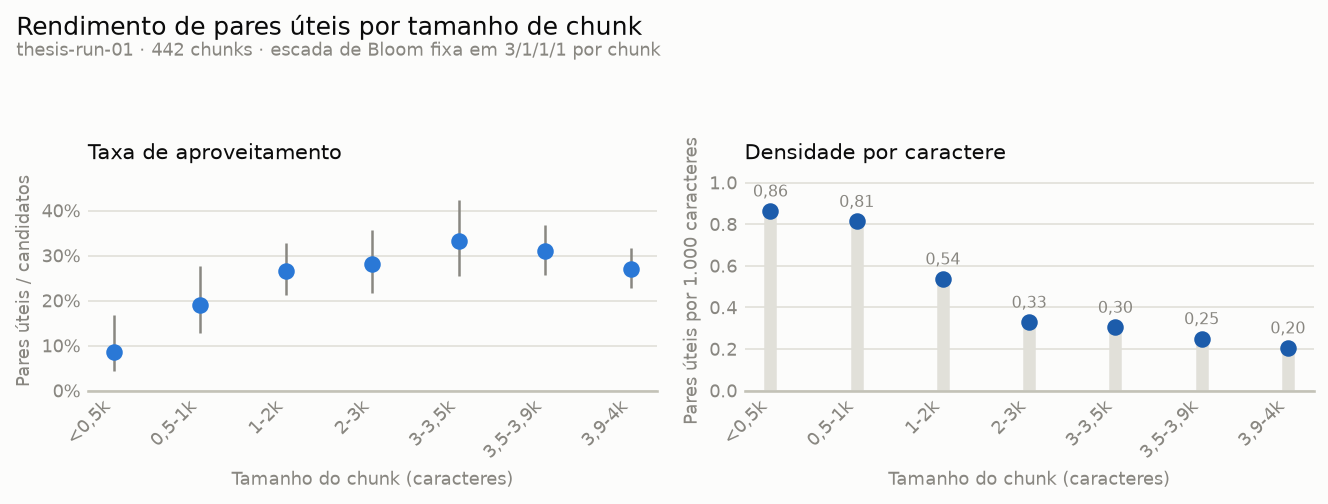

In [16]:
def plot_chunk_yield(
    faixas: pd.DataFrame,
    *,
    figsize: tuple[float, float] = (9.0, 3.4),
    title: str | None = None,
    subtitle: str | None = None,
) -> tuple[Figure, tuple[Axes, Axes]]:
    """Desenha taxa e densidade de pares uteis por faixa de tamanho de chunk.

    Os dois paineis usam base em zero: a taxa e uma proporcao, e a densidade
    so e comparavel entre faixas se o comprimento do traco for proporcional ao
    valor.

    Args:
        faixas: Frame de `band_yield`.
        figsize: Largura e altura da figura em polegadas.
        title: Titulo da figura. `None` omite.
        subtitle: Linha de procedencia sob o titulo. `None` omite.

    Returns:
        A figura e o par de eixos (taxa, densidade).
    """
    fig, (ax_taxa, ax_dens) = plt.subplots(1, 2, figsize=figsize, dpi=150)
    fig.patch.set_facecolor(SURFACE)
    posicoes = range(len(faixas))

    for ax in (ax_taxa, ax_dens):
        ax.set_facecolor(SURFACE)
        ax.set_xticks(list(posicoes))
        ax.set_xticklabels(faixas.index, rotation=45, ha="right")
        ax.yaxis.grid(True, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
        ax.tick_params(colors=MUTED, labelsize=8.5, length=0)
        for side, spine in ax.spines.items():
            spine.set_visible(side == "bottom")
            spine.set_color(AXIS)
        ax.set_xlabel("Tamanho do chunk (caracteres)", color=MUTED, fontsize=8.5)

    ax_taxa.vlines(list(posicoes), faixas["ic_lo"], faixas["ic_hi"], color=MUTED, linewidth=1.2)
    ax_taxa.scatter(list(posicoes), faixas["taxa"], s=48, color=BLOOM_RAMP[2], zorder=3)
    # Base em zero (a taxa e proporcao), topo ajustado aos dados: com a
    # definicao estrita de util as taxas ficam longe de 100% e um eixo cheio
    # esconderia as diferencas entre faixas.
    ax_taxa.set_ylim(0, min(1.0, max(0.4, float(faixas["ic_hi"].max()) * 1.15)))
    ax_taxa.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
    ax_taxa.set_ylabel("Pares úteis / candidatos", color=MUTED, fontsize=8.5)
    ax_taxa.set_title("Taxa de aproveitamento", loc="left", fontsize=10, color=INK)

    ax_dens.vlines(list(posicoes), 0, faixas["uteis_por_1k"], color=GRID, linewidth=6)
    ax_dens.scatter(list(posicoes), faixas["uteis_por_1k"], s=48, color=BLOOM_RAMP[3], zorder=3)
    # Folga no topo para o rotulo da faixa mais densa nao encostar na moldura.
    ax_dens.set_ylim(0, float(faixas["uteis_por_1k"].max()) * 1.22)
    ax_dens.set_ylabel("Pares úteis por 1.000 caracteres", color=MUTED, fontsize=8.5)
    ax_dens.set_title("Densidade por caractere", loc="left", fontsize=10, color=INK)
    for x, valor in zip(posicoes, faixas["uteis_por_1k"]):
        ax_dens.annotate(
            f"{valor:.2f}".replace(".", ","), (x, valor), textcoords="offset points",
            xytext=(0, 7),
            ha="center", fontsize=7.5, color=MUTED,
        )

    if title:
        fig.suptitle(title, x=0.02, ha="left", fontsize=12, color=INK)
    if subtitle:
        fig.text(0.02, 0.9, subtitle, ha="left", fontsize=8.5, color=MUTED)
    sns.despine(fig=fig, left=True)
    fig.tight_layout(rect=(0, 0, 1, 0.88 if title else 1.0))
    return fig, (ax_taxa, ax_dens)


fig_chunk, _ = plot_chunk_yield(
    faixas,
    title="Rendimento de pares úteis por tamanho de chunk",
    subtitle=f"{RUN_ID} · {len(chunks)} chunks · escada de Bloom fixa em 3/1/1/1 por chunk",
)
plt.show()

## Aproveitamento: orçamento da escada, chunk útil e extremos

Três contas que fecham a leitura do estágio, e que a seção anterior mede em
taxa mas não em contagem.

**Orçamento da escada.** O `bloom_distribution` travado em 3/1/1/1 gasta 3 dos
6 pares de cada chunk em `remember`, que por configuração do juiz nunca conta
como par útil. Candidatos são portanto sempre **metade** do que o gerador
produz, qualquer que seja o número de chunks.

**Chunk útil.** Um chunk é *aproveitado* quando rende ao menos um par útil. A
distinção importa porque a taxa média esconde a forma da distribuição: um
rendimento médio de 0,8 par por chunk é compatível tanto com todos os chunks
rendendo pouco quanto com metade rendendo nada.

**Extremos.** O menor e o maior chunk, com o perfil completo do documento a que
pertencem. É o que diagnostica resto de chunking: um chunk minúsculo com irmãos
grandes é sobra da última janela, não documento curto.

**Cobertura do corpus.** As duas distribuições (por chunk e por documento)
mais a curva de concentração. A curva ordena os documentos do que mais rende
ao que menos e acumula os pares úteis, então a leitura é direta: "os X% que mais
rendem concentram Y% do corpus útil". A diagonal é a referência de um corpus
onde todo documento contribui igual, e a distância até ela é a desigualdade.
**Concentração mecânica vs. substantiva.** O painel da direita traz três
curvas, e cada uma é um contrafactual diferente:

- **igual por documento** (diagonal): todo documento rende a mesma coisa. Como o
  orçamento é proporcional ao número de chunks, é também a curva que sairia se
  todo documento tivesse a mesma quantidade de chunks.
- **igual por chunk** (tracejada): todo chunk rende a mesma coisa,
  mas os documentos têm as contagens de chunks que de fato têm. É a
  concentração do orçamento de candidatos, e sobe acima da diagonal
  exclusivamente por causa do chunking. Escalar por uma constante não muda uma
  curva de concentração, então ela é idêntica à curva dos chunks por documento.
- **observado** (cheia): os pares úteis de verdade.

Os dois últimos são expectativas, e cada rótulo nomeia a hipótese que a curva
assume. É o paralelismo entre "igual por chunk" e "igual por documento" que
torna a decomposição legível sem prosa.

A leitura é aditiva. Da diagonal até a tracejada é a desigualdade que vem do
chunking; da tracejada até a cheia é a que vem do rendimento diferencial por
chunk. Os Ginis dão a mesma decomposição em número. Na mesma
direção, um documento de um único chunk tem só 3 candidatos, e sair zero com 3
sorteios é comum: o baseline binomial é o que distingue efeito de amostra de
material improdutivo.

As duas distribuições usam **ênfase**, não paleta categórica: o zero em cinza
de recuo, o resto no azul de acento, e o valor sempre acima da barra para o
rótulo não depender do contraste do preenchimento. A escolha do cinza (`MUTED`)
foi validada em contraste contra a superfície e em separação sob daltonismo
contra o azul, então a distinção ocioso/aproveitado sobrevive em escala de
cinza.

In [17]:
def ladder_accounting(pairs: pd.DataFrame) -> pd.DataFrame:
    """Contabiliza o orcamento da escada de Bloom por nivel.

    Args:
        pairs: Frame com `bloom_level`, `candidato` e `util`.

    Returns:
        Frame indexado por nivel (na ordem de `BLOOM_ORDER`, mais `TOTAL`) com
        `pares` gerados, `candidatos` a par util, `uteis` e a taxa de
        aproveitamento sobre os candidatos.
    """
    table = (
        pairs.groupby("bloom_level", observed=True)
        .agg(pares=("util", "size"), candidatos=("candidato", "sum"), uteis=("util", "sum"))
        .reindex(BLOOM_ORDER)
    )
    table.loc["TOTAL"] = table.sum()
    table["taxa_util"] = table["uteis"] / table["candidatos"]
    return table


def chunk_utilization(chunks: pd.DataFrame) -> pd.DataFrame:
    """Distribuicao de pares uteis por chunk, com as duas bases de leitura.

    Args:
        chunks: Frame de `chunk_table`.

    Returns:
        Frame indexado pelo numero de pares uteis (0 ate o maximo de candidatos
        por chunk) com `chunks`, a fracao sobre todos os chunks e a fracao
        sobre os chunks aproveitados.
    """
    teto = int(chunks["candidatos"].max())
    table = (
        chunks["uteis"]
        .value_counts()
        .reindex(range(teto + 1), fill_value=0)
        .sort_index()
        .to_frame("chunks")
    )
    table.index.name = "uteis_no_chunk"
    table["fracao_dos_chunks"] = table["chunks"] / len(chunks)
    aproveitados = len(chunks) - int(table.loc[0, "chunks"])
    table["fracao_dos_aproveitados"] = (table["chunks"] / aproveitados).mask(table.index == 0)
    return table


def utilization_by_band(chunks: pd.DataFrame) -> pd.DataFrame:
    """Chunk aproveitado vs. ocioso por faixa de tamanho.

    Args:
        chunks: Frame de `chunk_table`, com a coluna `faixa`.

    Returns:
        Frame indexado por `faixa` com `chunks`, `aproveitados`, a taxa de
        aproveitamento e os pares uteis por chunk.
    """
    usado = chunks["uteis"] > 0
    table = chunks.assign(usado=usado).groupby("faixa", observed=True).agg(
        chunks=("usado", "size"), aproveitados=("usado", "sum"), uteis=("uteis", "sum")
    )
    table["taxa_aproveitamento"] = table["aproveitados"] / table["chunks"]
    table["uteis_por_chunk"] = table["uteis"] / table["chunks"]
    return table


escada = ladder_accounting(pairs)
display(escada)
candidatos = int(escada.loc["TOTAL", "candidatos"])
print(f"candidatos a par util: {candidatos} de {len(pairs)} pares gerados"
      f" ({candidatos / len(pairs):.1%}), {int(escada.loc['TOTAL', 'uteis'])} uteis"
      f" ({escada.loc['TOTAL', 'taxa_util']:.1%} dos candidatos,"
      f" {escada.loc['TOTAL', 'uteis'] / len(pairs):.1%} dos gerados)")

aproveitados = int((chunks["uteis"] > 0).sum())
ociosos = len(chunks) - aproveitados
print(f"\nchunks aproveitados: {aproveitados} de {len(chunks)}"
      f" ({aproveitados / len(chunks):.1%}) · ociosos: {ociosos} ({ociosos / len(chunks):.1%})")
print(f"pares uteis por chunk: {chunks['uteis'].mean():.2f} no geral,"
      f" {chunks['uteis'].sum() / aproveitados:.2f} entre os aproveitados"
      f" (teto de {int(chunks['candidatos'].max())})")
display(chunk_utilization(chunks))
display(utilization_by_band(chunks))

por_doc_usado = chunks.assign(usado=chunks["uteis"] > 0).groupby("source_gdrive_id")["usado"].sum()
com_uso = int((por_doc_usado > 0).sum())
print(f"documentos com ao menos um chunk aproveitado: {com_uso} de {len(por_doc_usado)}"
      f" ({com_uso / len(por_doc_usado):.1%})")

,pares,candidatos,uteis,taxa_util
bloom_level,,,,
remember,1326,0,0,NaN
understand,442,442,115,0.260181
analyze,442,442,146,0.330317
evaluate,442,442,93,0.210407
TOTAL,2652,1326,354,0.266968


candidatos a par util: 1326 de 2652 pares gerados (50.0%), 354 uteis (26.7% dos candidatos, 13.3% dos gerados)

chunks aproveitados: 242 de 442 (54.8%) · ociosos: 200 (45.2%)
pares uteis por chunk: 0.80 no geral, 1.46 entre os aproveitados (teto de 3)


,chunks,fracao_dos_chunks,fracao_dos_aproveitados
uteis_no_chunk,,,
0,200,0.452489,NaN
1,151,0.341629,0.623967
2,70,0.158371,0.289256
3,21,0.047511,0.086777


,chunks,aproveitados,uteis,taxa_aproveitamento,uteis_por_chunk
faixa,,,,,
"<0,5k",27,6,7,0.222222,0.259259
"0,5-1k",35,13,20,0.371429,0.571429
1-2k,75,42,60,0.560000,0.800000
2-3k,51,33,43,0.647059,0.843137
"3-3,5k",39,26,39,0.666667,1.000000
"3,5-3,9k",87,51,81,0.586207,0.931034
"3,9-4k",128,71,104,0.554688,0.812500


documentos com ao menos um chunk aproveitado: 128 de 214 (59.8%)


In [18]:
def document_chunk_profile(pairs: pd.DataFrame, chunk_id: str) -> pd.DataFrame:
    """Perfil de todos os chunks do documento a que um chunk pertence.

    Responde se um chunk minusculo e documento curto ou resto da ultima
    janela do chunker: com irmaos grandes, e resto.

    Args:
        pairs: Frame de pares QA (use o frame BRUTO para ver os chunks que o
            piso removeu).
        chunk_id: Chunk cujo documento sera perfilado.

    Returns:
        Frame indexado por `chunk_id`, na ordem em que os chunks aparecem no
        artefato, com `context_chars` e as contagens de pares do chunk.
    """
    documento = pairs.loc[pairs["chunk_id"] == chunk_id, "source_gdrive_id"].iloc[0]
    do_documento = pairs[pairs["source_gdrive_id"] == documento]
    perfil = do_documento.groupby("chunk_id", sort=False).agg(
        source_filename=("source_filename", "first"),
        context_chars=("context_chars", "max"),
        gerados=("bloom_level", "size"),
    )
    perfil["e_o_chunk"] = perfil.index == chunk_id
    return perfil


def chunk_extremes(chunks: pd.DataFrame) -> pd.DataFrame:
    """Menor e maior chunk da analise, com o rendimento de cada um.

    Args:
        chunks: Frame de `chunk_table`.

    Returns:
        Frame com duas linhas (`menor`, `maior`).
    """
    extremos = pd.concat(
        [chunks.nsmallest(1, "chars"), chunks.nlargest(1, "chars")],
        keys=["menor", "maior"],
        names=["extremo", "chunk_id"],
    )
    return extremos[["source_gdrive_id", "chars", "candidatos", "uteis", "faixa"]]


extremos = chunk_extremes(chunks)
print("extremos de tamanho na analise (apos o piso de"
      f" {MIN_CHUNK_CHARS} chars)")
display(extremos)
print(f"chunks no teto de 4000 chars: {int((chunks['chars'] == 4000).sum())}"
      f" · entre 3990 e 3999: {int(((chunks['chars'] >= 3990) & (chunks['chars'] < 4000)).sum())}")

for extremo, chunk_id in extremos.index:
    print(f"\ndocumento do chunk {extremo} ({chunk_id})")
    display(document_chunk_profile(df, chunk_id))

# Os chunks que o piso removeu, perfilados no frame BRUTO: todos tem irmaos
# grandes no mesmo documento, entao sao restos da ultima janela do chunker e
# nao documentos curtos. O menor documento do corpus e bem maior que eles.
print("\nchunks removidos pelo piso, no contexto do seu documento")
for chunk_id in chunks_descartados.index:
    display(document_chunk_profile(bruto, chunk_id))

total_por_doc = bruto.groupby(["source_gdrive_id", "chunk_id"], observed=True)["context_chars"].max()
print(f"menor documento do corpus (soma dos chunks):"
      f" {int(total_por_doc.groupby(level=0).sum().min())} chars")

extremos de tamanho na analise (apos o piso de 100 chars)


,,source_gdrive_id,chars,candidatos,uteis,faixa
extremo,chunk_id,,,,,
menor,e97d4e4419fbcbb5,1PAeQJbpnL4U4xCZy2cAKRIz6ZWkyFmp_,137,3,0,"<0,5k"
maior,87670fcce375603c,17No8g6d84dD2lu6NYrSuniV4myJUTUyz,4000,3,1,"3,9-4k"


chunks no teto de 4000 chars: 1 · entre 3990 e 3999: 27

documento do chunk menor (e97d4e4419fbcbb5)


,source_filename,context_chars,gerados,e_o_chunk
chunk_id,,,,
5aaf456327af4a5c,Dani_Henrique_15-11-2025_BARRA_08.MOV,3965,6,False
e97d4e4419fbcbb5,Dani_Henrique_15-11-2025_BARRA_08.MOV,137,6,True



documento do chunk maior (87670fcce375603c)


...


chunks removidos pelo piso, no contexto do seu documento


,source_filename,context_chars,gerados,e_o_chunk
chunk_id,,,,
5bdeac1aef468e40,VID_20250718_102720450.mp4,2994,6,False
d0faeca945a8c39b,VID_20250718_102720450.mp4,3982,6,False
3f7ca42c5bcce6c4,VID_20250718_102720450.mp4,24,6,True


,source_filename,context_chars,gerados,e_o_chunk
chunk_id,,,,
4e90212a67ac8e20,MVI_8683.MOV,3050,6,False
da3b75f2304ed27a,MVI_8683.MOV,3999,6,False
2d41928acb1f750d,MVI_8683.MOV,3982,6,False
38b8b0cebefb8e88,MVI_8683.MOV,59,6,True


,source_filename,context_chars,gerados,e_o_chunk
chunk_id,,,,
14d210ee30c1016e,Dani Borges 31-10-2025.MVI.MOV,3951,6,False
f610957c458f6796,Dani Borges 31-10-2025.MVI.MOV,60,6,True


menor documento do corpus (soma dos chunks): 215 chars


,chunks,fracao
uteis_no_chunk,,
0,200,0.452489
1,151,0.341629
2,70,0.158371
3,21,0.047511


,documentos,fracao
uteis_no_documento,,
0,86,0.401869
1,46,0.214953
2,45,0.210280
3,14,0.065421
4,10,0.046729
5,7,0.032710
6-10,3,0.014019
11+,3,0.014019


top   5% dos documentos: 35.6% dos pares uteis
top  10% dos documentos: 47.5% dos pares uteis
top  25% dos documentos: 71.2% dos pares uteis
top  50% dos documentos: 94.1% dos pares uteis


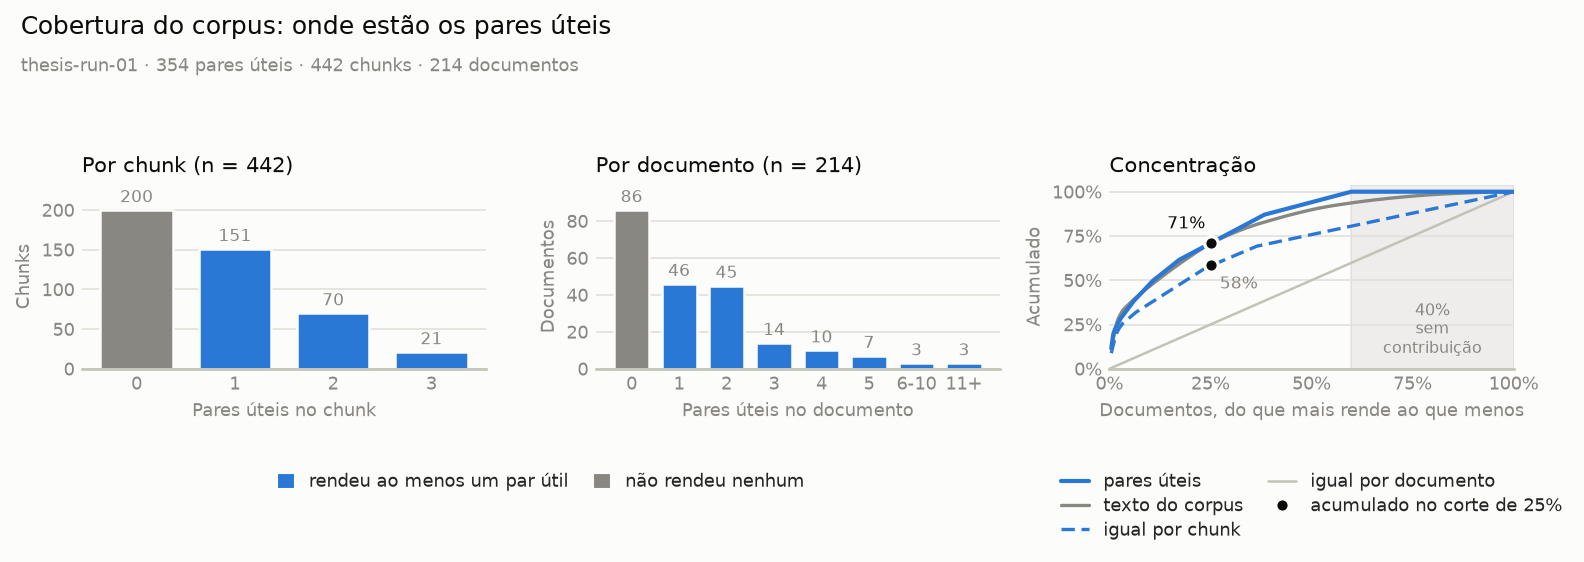

In [19]:
from matplotlib.patches import Patch

# Corte de referencia da curva de concentracao: vira tick no eixo x e rotulo
# junto do marcador, entao a tupla e a unica fonte dos dois. Um corte so, e nao
# dois: perto da origem as tres curvas convergem e nao ha posicao livre para o
# rotulo (a direita bate na tracejada, acima na observada, a esquerda nos ticks
# do eixo y). Em 25% as tres estao bem separadas. Os demais cortes ficam na
# tabela de `concentration_shares`, que e onde se lê numero, nao na figura.
MARCAS_REFERENCIA = (0.25,)

# Marcador dos cortes em tinta neutra, nao num terceiro azul nem numa cor de
# criterio: ele nao e uma serie, e uma anotacao. INK separa das duas curvas
# (dE 45 contra o azul, 66 contra o cinza) e passa contraste contra a
# superficie, e o anel da cor do fundo o mantem legivel sobre a linha.
MARCA_COR = INK
MARCA_TAMANHO = 6.5

# Forma de ênfase, não paleta categórica: um tom de acento para o que rendeu e o
# cinza de recuo do notebook para o que não rendeu. `MUTED` (#898781) foi
# escolhido por passar contraste >= 3:1 contra a superfície e separação sob
# deuteranopia/protanopia/tritanopia contra o azul, então a leitura "ocioso vs
# aproveitado" sobrevive em escala de cinza e sob daltonismo.
OCIOSO, APROVEITADO = MUTED, BLOOM_RAMP[2]

# Cauda dobrada em duas faixas em vez de um eixo de 0 a 41 quase todo vazio.
DOC_BINS = [0, 1, 2, 3, 4, 5, 6, 11, float("inf")]
DOC_LABELS = ["0", "1", "2", "3", "4", "5", "6-10", "11+"]


def coverage_distributions(
    chunks: pd.DataFrame, pairs: pd.DataFrame
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Distribuicoes de pares uteis por chunk e por documento, e a concentracao.

    Args:
        chunks: Frame de `chunk_table`.
        pairs: Frame de pares QA, usado so para conferir o total.

    Returns:
        Tripla (`por_chunk`, `por_documento`, `concentracao`). As duas
        primeiras sao contagens com a fracao correspondente; a terceira tem
        duas curvas acumuladas sobre os documentos ordenados do maior para o
        menor: `uteis_acum` responde "quantos documentos concentram quanto do
        corpus util", e `candidatos_acum` e a mesma conta sobre o orcamento de
        candidatos. Como o orcamento e 3 pares por chunk, essa segunda curva e
        a concentracao que restaria se todo chunk rendesse igual: a distancia
        entre as duas isola a desigualdade de rendimento da desigualdade de
        chunking. `chars_acum` e a mesma conta sobre o texto bruto: e a
        desigualdade do proprio corpus, antes de qualquer decisao de metodo, e
        serve de referencia para saber se o pipeline herda ou cria a
        concentracao que se observa no resultado.
    """
    teto = int(chunks["candidatos"].max())
    por_chunk = (
        chunks["uteis"]
        .value_counts()
        .reindex(range(teto + 1), fill_value=0)
        .sort_index()
        .to_frame("chunks")
    )
    por_chunk.index.name = "uteis_no_chunk"
    por_chunk["fracao"] = por_chunk["chunks"] / len(chunks)

    por_doc = chunks.groupby("source_gdrive_id")["uteis"].sum()
    faixa = pd.cut(por_doc, DOC_BINS, labels=DOC_LABELS, right=False)
    por_documento = faixa.value_counts().reindex(DOC_LABELS).to_frame("documentos")
    por_documento.index.name = "uteis_no_documento"
    por_documento["fracao"] = por_documento["documentos"] / len(por_doc)

    ordenado = por_doc.sort_values(ascending=False)
    # Cada quantidade e ordenada por si mesma: e o que faz de cada curva uma
    # curva de concentracao propria, comparavel a diagonal.
    por_documento_col = chunks.groupby("source_gdrive_id")
    candidatos = por_documento_col["candidatos"].sum().sort_values(ascending=False)
    caracteres = por_documento_col["chars"].sum().sort_values(ascending=False)
    concentracao = pd.DataFrame(
        {
            "documentos_acum": [i / len(ordenado) for i in range(1, len(ordenado) + 1)],
            "uteis_acum": ordenado.cumsum().to_numpy() / ordenado.sum(),
            "candidatos_acum": candidatos.cumsum().to_numpy() / candidatos.sum(),
            "chars_acum": caracteres.cumsum().to_numpy() / caracteres.sum(),
        }
    )

    assert int(por_chunk["chunks"].sum()) == len(chunks)
    assert int(por_documento["documentos"].sum()) == len(por_doc)
    assert int(chunks["uteis"].sum()) == int(pairs["util"].sum())
    return por_chunk, por_documento, concentracao


def _bar_panel(
    ax: Axes,
    contagens: pd.Series,
    *,
    xlabel: str,
    ylabel: str,
    titulo: str,
) -> None:
    """Desenha um painel de barras com o zero em recuo e rotulo acima da barra.

    Args:
        ax: Eixo de destino.
        contagens: Serie indexada pelas classes, na ordem de plotagem.
        xlabel: Rotulo do eixo x.
        ylabel: Rotulo do eixo y.
        titulo: Titulo do painel.
    """
    posicoes = range(len(contagens))
    cores = [OCIOSO if str(rotulo) == "0" else APROVEITADO for rotulo in contagens.index]
    ax.bar(posicoes, contagens.to_numpy(), width=0.74, color=cores,
           edgecolor=SURFACE, linewidth=1.2, zorder=2)
    # Rotulo sempre acima da barra: nunca depende do contraste do preenchimento
    # e nunca e cortado por barra curta.
    for x, valor in zip(posicoes, contagens.to_numpy()):
        ax.text(x, valor + contagens.max() * 0.025, f"{int(valor)}",
                ha="center", va="bottom", fontsize=8, color=MUTED, zorder=3)
    ax.set_xticks(list(posicoes))
    ax.set_xticklabels([str(r) for r in contagens.index])
    ax.set_ylim(0, contagens.max() * 1.16)
    ax.set_xlabel(xlabel, color=MUTED, fontsize=8.5)
    ax.set_ylabel(ylabel, color=MUTED, fontsize=8.5)
    ax.set_title(titulo, loc="left", fontsize=10, color=INK)


def plot_coverage(
    por_chunk: pd.DataFrame,
    por_documento: pd.DataFrame,
    concentracao: pd.DataFrame,
    *,
    sem_contribuicao: float,
    figsize: tuple[float, float] = (10.5, 3.6),
    title: str | None = None,
    subtitle: str | None = None,
    mostrar_orcamento: bool = True,
) -> tuple[Figure, tuple[Axes, Axes, Axes]]:
    """Desenha a cobertura do corpus em tres paineis.

    Os dois primeiros sao as distribuicoes (por chunk e por documento) em
    contagem absoluta, com o zero em recuo. O terceiro acumula os pares uteis
    sobre os documentos ordenados por rendimento, que e a leitura de cobertura:
    a diagonal seria um corpus onde todo documento contribui igual.

    Args:
        por_chunk: Frame de `coverage_distributions`.
        por_documento: Frame de `coverage_distributions`.
        concentracao: Frame de `coverage_distributions`.
        sem_contribuicao: Fracao de documentos sem nenhum par util, usada
            para sombrear o plato final da curva.
        figsize: Largura e altura da figura em polegadas.
        title: Titulo da figura. `None` omite.
        subtitle: Linha de procedencia sob o titulo. `None` omite.
        mostrar_orcamento: Desenha a curva do orcamento de candidatos, que e o
            mecanismo (o chunking atenua a desigualdade de partida). `False`
            deixa so a comparacao que carrega o argumento, texto bruto contra
            resultado, para a versao de artigo.

    Returns:
        A figura e os tres eixos.
    """
    fig, (ax_chunk, ax_doc, ax_cob) = plt.subplots(1, 3, figsize=figsize, dpi=150)
    fig.patch.set_facecolor(SURFACE)
    for ax in (ax_chunk, ax_doc, ax_cob):
        ax.set_facecolor(SURFACE)
        ax.yaxis.grid(True, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
        ax.tick_params(colors=MUTED, labelsize=8.5, length=0)
        for side, spine in ax.spines.items():
            spine.set_visible(side == "bottom")
            spine.set_color(AXIS)

    _bar_panel(
        ax_chunk, por_chunk["chunks"], xlabel="Pares úteis no chunk", ylabel="Chunks",
        titulo=f"Por chunk (n = {int(por_chunk['chunks'].sum())})",
    )
    _bar_panel(
        ax_doc, por_documento["documentos"], xlabel="Pares úteis no documento",
        ylabel="Documentos",
        titulo=f"Por documento (n = {int(por_documento['documentos'].sum())})",
    )

    # Painel de cobertura: serie unica, entao sem legenda, com a diagonal de
    # referencia em hairline e rotulos diretos so nos dois pontos que importam.
    # Diagonal no tom do eixo, um passo acima do grid: precisa ser visivel
    # tambem como amostra na legenda, sem competir com a curva. Fica em peso de
    # referencia, e e a legenda que a nomeia, nao um rotulo inline (que colidia
    # com as anotacoes e cujo angulo dependia do figsize).
    ax_cob.plot([0, 1], [0, 1], color=AXIS, linewidth=1.2, zorder=1)
    if mostrar_orcamento:
        # Mesma cor da observada, tracejada: as duas medem pares, e um segundo
        # tom de azul reprovaria a separacao de visao normal (o tracejado
        # carrega a distincao sem custo de cor).
        ax_cob.plot(concentracao["documentos_acum"], concentracao["candidatos_acum"],
                    color=APROVEITADO, linewidth=1.6, linestyle=(0, (4, 2)), zorder=2)
    # Texto bruto em cinza de texto: mede outra grandeza (caracteres, nao
    # pares), entao ganha cor propria em vez de estilo de traco. Ela quase
    # coincide com a observada, e essa coincidencia e o argumento da figura.
    ax_cob.plot(concentracao["documentos_acum"], concentracao["chars_acum"],
                color=MUTED, linewidth=1.6, zorder=3)
    ax_cob.plot(concentracao["documentos_acum"], concentracao["uteis_acum"],
                color=APROVEITADO, linewidth=2.0, zorder=4)
    for marca in MARCAS_REFERENCIA:
        alvo = concentracao.iloc[(concentracao["documentos_acum"] - marca).abs().idxmin()]
        ax_cob.plot([alvo["documentos_acum"]], [alvo["uteis_acum"]], marker="o",
                    markersize=MARCA_TAMANHO, color=MARCA_COR,
                    markeredgecolor=SURFACE, markeredgewidth=1.6, zorder=5)
        # Cada rotulo na diagonal, para o lado livre da SUA curva: o da
        # observada acima e a esquerda, o da tracejada abaixo e a direita. As
        # curvas sobem, entao esses dois quadrantes ficam vazios.
        ax_cob.annotate(
            f"{alvo['uteis_acum']:.0%}",
            (alvo["documentos_acum"], alvo["uteis_acum"]),
            textcoords="offset points", xytext=(-3, 5), ha="right", va="bottom",
            fontsize=8, color=INK,
        )
        if marca == 0.25 and mostrar_orcamento:
            # Marcador vazado no mesmo corte, para o valor do orcamento ficar
            # ancorado na sua curva em vez de solto no meio do painel.
            ax_cob.plot(
                [alvo["documentos_acum"]], [alvo["candidatos_acum"]], marker="o",
                markersize=MARCA_TAMANHO, color=MARCA_COR, markeredgecolor=SURFACE,
                markeredgewidth=1.6, zorder=5,
            )
            ax_cob.annotate(
                f"{alvo['candidatos_acum']:.0%}",
                (alvo["documentos_acum"], alvo["candidatos_acum"]),
                textcoords="offset points", xytext=(4, -5), ha="left", va="top",
                fontsize=8, color=MUTED,
            )
    ax_cob.axvspan(1 - sem_contribuicao, 1, color=OCIOSO, alpha=0.12, zorder=0)
    ax_cob.text(1 - sem_contribuicao / 2, 0.06, f"{sem_contribuicao:.0%}\nsem\ncontribuição",
                ha="center", va="bottom", fontsize=7.5, color=MUTED, linespacing=1.25)
    ax_cob.set_xlim(0, 1)
    ax_cob.set_ylim(0, 1.04)
    # Ticks nos proprios cortes de referencia: o eixo passa a dizer "onde", e o
    # rotulo junto do marcador fica so com o valor.
    ax_cob.set_xticks([0.0, *MARCAS_REFERENCIA, 0.5, 0.75, 1.0])
    ax_cob.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
    ax_cob.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
    ax_cob.set_xlabel("Documentos, do que mais rende ao que menos", color=MUTED, fontsize=8.5)
    ax_cob.set_ylabel("Acumulado", color=MUTED, fontsize=8.5)
    ax_cob.set_title("Concentração", loc="left", fontsize=10, color=INK)

    if title:
        fig.suptitle(title, x=0.02, y=0.975, ha="left", va="top", fontsize=12, color=INK)
    if subtitle:
        fig.text(0.02, 0.895, subtitle, ha="left", va="top", fontsize=8.5, color=MUTED)

    sns.despine(fig=fig, left=True)
    # A faixa reservada embaixo hospeda as duas legendas, posicionadas depois
    # do layout: cada uma se centra no bloco de paineis que ela explica, o que
    # exige as coordenadas finais dos eixos.
    fig.tight_layout(rect=(0, 0.175, 1, 0.855 if title else 1.0))

    barras = (ax_chunk.get_position().x0 + ax_doc.get_position().x1) / 2
    curva = (ax_cob.get_position().x0 + ax_cob.get_position().x1) / 2
    fig.legend(
        handles=[
            Patch(facecolor=APROVEITADO, edgecolor=SURFACE, label="rendeu ao menos um par útil"),
            Patch(facecolor=OCIOSO, edgecolor=SURFACE, label="não rendeu nenhum"),
        ],
        frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(barras, 0.155),
        bbox_transform=fig.transFigure, fontsize=8.5, handlelength=1.0, handleheight=1.0,
        columnspacing=1.4,
    )
    fig.legend(
        handles=[
            Line2D([], [], color=APROVEITADO, linewidth=2.0, label="pares úteis"),
            Line2D([], [], color=MUTED, linewidth=1.6, label="texto do corpus"),
            *(
                [
                    Line2D([], [], color=APROVEITADO, linewidth=1.6,
                           linestyle=(0, (4, 2)), label="igual por chunk")
                ]
                if mostrar_orcamento
                else []
            ),
            Line2D([], [], color=AXIS, linewidth=1.2, label="igual por documento"),
            Line2D([], [], color=MARCA_COR, linestyle="none", marker="o",
                   markersize=MARCA_TAMANHO, markeredgecolor=SURFACE, markeredgewidth=1.6,
                   label="acumulado no corte de "
                   + ", ".join(f"{marca:.0%}" for marca in MARCAS_REFERENCIA)),
        ],
        frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(curva, 0.155),
        bbox_transform=fig.transFigure, fontsize=8.5, handlelength=1.6,
        columnspacing=1.4, labelspacing=0.35,
    )
    return fig, (ax_chunk, ax_doc, ax_cob)


por_chunk, por_documento, concentracao = coverage_distributions(chunks, pairs)
display(por_chunk)
display(por_documento)

for marca in (0.05, 0.10, 0.25, 0.50):
    alvo = concentracao.iloc[(concentracao["documentos_acum"] - marca).abs().idxmin()]
    print(f"top {marca:>4.0%} dos documentos: {alvo['uteis_acum']:.1%} dos pares uteis")

fig_cobertura, _ = plot_coverage(
    por_chunk,
    por_documento,
    concentracao,
    sem_contribuicao=float(por_documento.loc["0", "fracao"]),
    title="Cobertura do corpus: onde estão os pares úteis",
    subtitle=(
        f"{RUN_ID} · {int(pairs['util'].sum())} pares úteis"
        f" · {len(chunks)} chunks · {chunks['source_gdrive_id'].nunique()} documentos"
    ),
)
plt.show()

In [20]:
from math import comb


def gini(valores: pd.Series) -> float:
    """Coeficiente de Gini de uma distribuicao de contagens.

    Args:
        valores: Serie de valores nao negativos.

    Returns:
        Coeficiente entre 0 (todos iguais) e 1 (tudo concentrado em um).
    """
    ordenado = valores.sort_values().to_numpy(dtype=float)
    n = len(ordenado)
    posicao = pd.RangeIndex(1, n + 1).to_numpy()
    return float((2 * (posicao * ordenado).sum()) / (n * ordenado.sum()) - (n + 1) / n)


def document_profile(chunks: pd.DataFrame) -> pd.DataFrame:
    """Perfil por documento: chunks, candidatos, pares uteis e taxa.

    `candidatos` e o numero de chunks vezes a escada de candidatos por chunk, o
    que torna explicito que o orcamento de um documento e funcao mecanica da
    sua contagem de chunks.

    Args:
        chunks: Frame de `chunk_table`.

    Returns:
        Frame indexado por `source_gdrive_id` com `chunks`, `chars`,
        `candidatos`, `uteis` e `taxa`.
    """
    perfil = chunks.groupby("source_gdrive_id").agg(
        chunks=("chars", "size"),
        chars=("chars", "sum"),
        candidatos=("candidatos", "sum"),
        uteis=("uteis", "sum"),
    )
    perfil["taxa"] = perfil["uteis"] / perfil["candidatos"]
    return perfil


def concentration_shares(perfil: pd.DataFrame, marcas: tuple[float, ...]) -> pd.DataFrame:
    """Fracao acumulada de candidatos e de pares uteis nos documentos do topo.

    Comparar as duas colunas separa a concentracao mecanica (candidatos, que
    seguem a contagem de chunks) da substantiva (uteis, que dependem tambem do
    rendimento por candidato).

    Args:
        perfil: Frame de `document_profile`.
        marcas: Fracoes de documentos a reportar, do topo para baixo.

    Returns:
        Frame indexado pelas marcas com as duas fracoes acumuladas.
    """
    linhas = {}
    for marca in marcas:
        corte = max(1, round(marca * len(perfil)))
        linhas[f"top {marca:.0%}"] = {
            coluna: float(
                perfil[coluna].sort_values(ascending=False).iloc[:corte].sum()
                / perfil[coluna].sum()
            )
            for coluna in ("candidatos", "uteis")
        }
    return pd.DataFrame(linhas).T


perfil = document_profile(chunks)

print("chunks por documento")
distribuicao_chunks = perfil["chunks"].value_counts().sort_index().to_frame("documentos")
distribuicao_chunks["fracao"] = distribuicao_chunks["documentos"] / len(perfil)
distribuicao_chunks["chunks_totais"] = distribuicao_chunks.index * distribuicao_chunks["documentos"]
distribuicao_chunks.index.name = "chunks_no_documento"
display(distribuicao_chunks)
display(perfil["chunks"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("chunks"))

print("extensao dos documentos: a desigualdade de partida")
display(perfil["chars"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_frame("chars"))
print(f"razao entre o maior e o menor documento: {perfil['chars'].max() / perfil['chars'].min():.0f}x")

print("Gini por documento, do texto bruto ao par util")
display(
    pd.Series(
        {
            "caracteres (materia-prima do corpus)": gini(perfil["chars"]),
            "candidatos (apos o chunking)": gini(perfil["candidatos"]),
            "pares uteis": gini(perfil["uteis"]),
            "taxa util/candidatos": gini(perfil["taxa"]),
        }
    ).to_frame("gini")
)

# O chunking atenua a desigualdade de extensao porque a janela arredonda para
# cima: qualquer documento leva um chunk completo, por curto que seja. Comparar
# os chunks reais com os que seriam proporcionais ao texto mede esse subsidio.
JANELA_CHARS = 4000
perfil["chunks_proporcionais"] = perfil["chars"] / JANELA_CHARS
quartis = pd.qcut(perfil["chars"], 4, labels=["Q1 mais curto", "Q2", "Q3", "Q4 mais longo"])
subsidio = perfil.groupby(quartis, observed=True).agg(
    documentos=("chars", "size"),
    chars=("chars", "sum"),
    chunks=("chunks", "sum"),
    chunks_proporcionais=("chunks_proporcionais", "sum"),
)
subsidio["subsidio"] = subsidio["chunks"] / subsidio["chunks_proporcionais"]
print("orcamento de chunks recebido vs. proporcional ao texto")
display(subsidio)

print("concentracao acumulada nos documentos do topo")
display(concentration_shares(perfil, (0.05, 0.10, 0.25, 0.50)))

# A massa de documentos sem nenhum par util e quase toda de documentos de um
# unico chunk, isto e, com apenas 3 candidatos. Com tao poucos sorteios, sair
# zero e comum mesmo sem o material ser improdutivo: e o baseline binomial que
# separa efeito de amostra de efeito de conteudo.
sem_nada = perfil[perfil["uteis"] == 0]
print(f"documentos sem nenhum par util: {len(sem_nada)} de {len(perfil)}")
display(sem_nada["chunks"].value_counts().sort_index().to_frame("documentos"))

um_chunk = perfil[perfil["chunks"] == 1]
taxa_um = float(um_chunk["uteis"].sum() / um_chunk["candidatos"].sum())
candidatos_por_chunk = int(chunks["candidatos"].max())
print(
    f"documentos de 1 chunk: {len(um_chunk)} · taxa {taxa_um:.1%}"
    f" · zero observado {int((um_chunk['uteis'] == 0).sum())}"
    f" ({(um_chunk['uteis'] == 0).mean():.1%})"
    f" · zero esperado sob independencia {(1 - taxa_um) ** candidatos_por_chunk:.1%}"
)
varios = perfil[perfil["chunks"] > 1]
print(
    f"documentos de 2+ chunks: {len(varios)}"
    f" · taxa {varios['uteis'].sum() / varios['candidatos'].sum():.1%}"
    f" · zero {int((varios['uteis'] == 0).sum())} ({(varios['uteis'] == 0).mean():.1%})"
)

print("\nrendimento por contagem de chunks do documento")
faixa_chunks = pd.cut(
    perfil["chunks"], [1, 2, 3, 5, 10, float("inf")],
    labels=["1", "2", "3-4", "5-9", "10+"], right=False,
)
rendimento = perfil.groupby(faixa_chunks, observed=True).agg(
    documentos=("uteis", "size"),
    candidatos=("candidatos", "sum"),
    uteis=("uteis", "sum"),
    sem_nada=("uteis", lambda serie: int((serie == 0).sum())),
)
rendimento["taxa"] = rendimento["uteis"] / rendimento["candidatos"]
rendimento["fracao_sem_nada"] = rendimento["sem_nada"] / rendimento["documentos"]
display(rendimento)

# Aglomeracao dentro do chunk: se os candidatos de um mesmo chunk passassem de
# forma independente, a distribuicao seria binomial. O desvio mede se os pares
# uteis se agrupam em menos chunks do que o azar preveria.
taxa_global = float(pairs.loc[pairs["candidato"], "util"].mean())
esperado = pd.Series(
    {
        k: len(chunks)
        * comb(candidatos_por_chunk, k)
        * taxa_global**k
        * (1 - taxa_global) ** (candidatos_por_chunk - k)
        for k in range(candidatos_por_chunk + 1)
    },
    name="binomial",
)
comparacao = por_chunk[["chunks"]].rename(columns={"chunks": "observado"}).join(esperado)
comparacao["chi2_parcial"] = (comparacao["observado"] - comparacao["binomial"]) ** 2 / comparacao[
    "binomial"
]
display(comparacao)
aproveitados = int((chunks["uteis"] > 0).sum())
print(
    f"chunks aproveitados: observado {aproveitados / len(chunks):.1%}"
    f" · sob independencia {1 - (1 - taxa_global) ** candidatos_por_chunk:.1%}"
)
print(
    f"media condicional: observada {chunks['uteis'].sum() / aproveitados:.2f}"
    f" · sob independencia"
    f" {candidatos_por_chunk * taxa_global / (1 - (1 - taxa_global) ** candidatos_por_chunk):.2f}"
    f" · piso por construcao 1,00 de {candidatos_por_chunk}"
)
print(f"chi2 = {comparacao['chi2_parcial'].sum():.1f} ({candidatos_por_chunk} g.l.)")

chunks por documento


,documentos,fracao,chunks_totais
chunks_no_documento,,,
1,136,0.635514,136
2,27,0.126168,54
3,37,0.172897,111
4,7,0.032710,28
6,1,0.004673,6
7,1,0.004673,7
9,1,0.004673,9
15,1,0.004673,15
17,1,0.004673,17


,chunks
count,214.000000
mean,2.065421
std,3.340662
min,1.000000
50%,1.000000
75%,2.000000
90%,3.000000
95%,4.000000
99%,16.740000
max,39.000000


extensao dos documentos: a desigualdade de partida


,chars
count,214.000000
mean,5778.042056
std,12221.112593
min,215.000000
5%,275.700000
25%,1074.750000
50%,2950.500000
75%,6929.750000
95%,12375.100000
max,134971.000000


...

,documentos
chunks,
1,78
2,4
3,4


documentos de 1 chunk: 136 · taxa 19.9% · zero observado 78 (57.4%) · zero esperado sob independencia 51.5%
documentos de 2+ chunks: 78 · taxa 29.7% · zero 8 (10.3%)

rendimento por contagem de chunks do documento


,documentos,candidatos,uteis,sem_nada,taxa,fracao_sem_nada
chunks,,,,,,
1,136,408,81,78,0.198529,0.573529
2,27,162,51,4,0.314815,0.148148
3-4,44,417,119,4,0.285372,0.090909
5-9,3,66,16,0,0.242424,0.000000
10+,4,273,87,0,0.318681,0.000000


,observado,binomial,chi2_parcial
uteis_no_chunk,,,
0,200,174.096681,3.854077
1,151,190.216744,8.085266
2,70,69.276469,0.007557
3,21,8.410106,18.847018


chunks aproveitados: observado 54.8% · sob independencia 60.6%
media condicional: observada 1.46 · sob independencia 1.32 · piso por construcao 1,00 de 3
chi2 = 30.8 (3 g.l.)


### Leitura: o dataset é desigual porque o corpus é desigual

Racionalização sobre os números das duas células acima e dos três painéis da
figura de cobertura. É o raciocínio completo; o texto do artigo carrega só a
conclusão.

**O ponto de partida já é desigual.** As transcrições variam de 215 a 134.971
caracteres, uma razão de **628 vezes** entre os extremos, com mediana de 2.950.
O Gini de caracteres por documento é **0,621**, e os 25% mais extensos
concentram **71,0%** de todo o texto, enquanto a metade menos extensa responde
por 10,2%. Isso é um dado de campo, não de método: reflete gravações que vão de
trocas de poucos segundos a entrevistas longas.

**O resultado reproduz esse patamar quase exatamente.** Os 25% de documentos
mais produtivos concentram **71,2%** dos pares úteis (Gini **0,665**), contra
os 71,0% dos caracteres. É a sobreposição das duas curvas no terceiro painel: o
desvio médio entre elas é de **2,4 pontos** percentuais ao longo de todo o
eixo, e o máximo de 6,3 pontos, em x = 60%, onde a curva dos pares já saturou
em 100% e a do texto ainda está em 93,7%.

A curva dos pares fica sistematicamente **acima** da do texto (área entre elas
de +0,022), e o Gini sobe de 0,621 para 0,665. Então o enunciado exato não é
que o pipeline apenas herda a desigualdade: ele a herda e a **amplifica
levemente**. A amplificação é pequena ao lado da desigualdade de partida, mas
não é zero, e vale enunciá-la assim em vez de arredondar para "herda".

**O caminho até lá, porém, não é direto.** É o que os três painéis mostram:

1. O *chunking* **atenua** a desigualdade de partida, porque a janela de 4.000
   caracteres arredonda para cima e garante um chunk completo a qualquer
   documento. O quartil mais curto recebe **6,9x** o orçamento de candidatos
   que lhe caberia em proporção ao texto, contra 1,18x do quartil mais longo,
   e o Gini cai para **0,418** (58,4% no corte de 25%). É a curva
   `igual por chunk`.
2. O **rendimento diferencial restaura** a desigualdade original: a taxa de
   aprovação por candidato é de **17,1%** na metade menos extensa do corpus
   contra **29,8%** na mais extensa (Spearman +0,353 entre extensão e taxa).
   Documentos curtos recebem orçamento generoso em relação ao seu texto e o
   convertem pior. É a distância entre `igual por chunk` e `observado`.

**Os 40,2% sem contribuição são a expressão mais direta disso.** 78 dos 86
(90,7%) são documentos de um único chunk, com apenas 3 candidatos cada, e taxa
de 19,9%. Sob essa taxa, a probabilidade de não produzir nenhum par com 3
tentativas é de 51,5%, então a ausência decorre **conjuntamente** da escassez
de material e do pequeno número de tentativas que dela resulta. Não há
evidência aqui para afirmar que o conteúdo desses documentos seja improdutivo
por natureza: mais da metade dos zeros é esperada por acaso.

**Uma inversão que precisa aparecer enquadrada.** Medida por caractere, a
metade menos extensa rende *mais* (0,437 par útil por mil caracteres contra
0,269). Não contradiz o acima: é o outro lado do arredondamento da janela, que
dá candidatos de sobra a documentos curtos. Quem calcular a densidade vai
encontrar essa inversão, e é melhor que ela esteja explicada do que pareça
contradição.

**Aglomeração dentro do chunk.** A média condicional de 1,46 par entre os
chunks aproveitados deve ser lida contra o piso de 1 par (33,3% do teto)
imposto pela condição de seleção, não contra zero: 151 dos 242 (62,4%)
produzem exatamente um par e só 21 (8,7%) esgotam os três. Contra um modelo de
independência, observam-se 54,8% de chunks aproveitados onde se esperariam
60,6%, e média condicional de 1,46 contra 1,32 ($\chi^2 = 30{,}8$, 3 g.l.):
os pares úteis se agrupam em menos chunks do que o azar preveria, o que
reforça a concentração em vez de atenuá-la.

## Eco de metadados: pares fiéis ao registro, não à fala

O prompt de geração recebe um bloco de metadados da entrevista (local, data,
participantes, contexto do evento; ver `qa/cep/metadata_context.py`). Em chunks
com pouco texto, o gerador cai nesse bloco e produz pares sobre a *entrevista*
em vez do relato ("Onde ocorreu a entrevista com D. Celia?" → "Barra de
Pelotas"). Como o mesmo bloco está no contexto do juiz, esses pares recebem
fidelidade 1,0 e entram na contagem de aprovados.

O fenômeno é quase inteiramente de `remember`, e é a evidência empírica da
razão para não tratar `remember` como par útil: sem informatividade no crivo,
uma pergunta sobre a data da própria entrevista é indistinguível de recall
factual legítimo. A marcação abaixo é uma **heurística lexical**, não um
classificador: conta o padrão, não decide caso a caso.

In [21]:
import re

# Resposta que cita a procedencia ("conforme indicado nos metadados") ou
# pergunta que toma a propria entrevista como objeto.
META_NA_RESPOSTA = re.compile(r"metadad", re.IGNORECASE)
META_NA_PERGUNTA = re.compile(
    r"\b(?:(?:[dn]?a|nesta) (?:entrevista|conversa)|o evento ocorreu|entrevistad[ao] em)\b",
    re.IGNORECASE,
)


def flag_metadata_echo(pairs: pd.DataFrame) -> pd.Series:
    """Marca pares que respondem sobre o registro da entrevista, nao sobre a fala.

    Heuristica lexical: casa a citacao explicita de metadados na resposta ou a
    referencia a propria entrevista na pergunta. Subestima parafrases e pode
    marcar um par legitimo que mencione a entrevista de passagem, entao serve
    para dimensionar o fenomeno, nao para filtrar o dataset.

    Args:
        pairs: Frame com as colunas `question` e `answer`.

    Returns:
        Serie booleana alinhada a `pairs`.
    """
    resposta = pairs["answer"].fillna("").str.contains(META_NA_RESPOSTA)
    pergunta = pairs["question"].fillna("").str.contains(META_NA_PERGUNTA)
    return resposta | pergunta


pairs["eco_meta"] = flag_metadata_echo(pairs)
aprovados = pairs[pairs["aprovado"]]
print(f"pares com eco de metadados: {int(pairs['eco_meta'].sum())} ({pairs['eco_meta'].mean():.1%})")
print(f"entre os aprovados: {int(aprovados['eco_meta'].sum())} ({aprovados['eco_meta'].mean():.1%})")
print(f"entre os pares uteis (acima de remember): {int(pairs.loc[pairs['util'], 'eco_meta'].sum())}")

por_nivel_eco = pd.DataFrame(
    {
        "pares": pairs.groupby("bloom_level", observed=True).size(),
        "aprovados": pairs.groupby("bloom_level", observed=True)["aprovado"].sum(),
        "aprovados_eco": aprovados.groupby("bloom_level", observed=True)["eco_meta"].sum(),
    }
).reindex(BLOOM_ORDER)
por_nivel_eco["aprovados_limpos"] = por_nivel_eco["aprovados"] - por_nivel_eco["aprovados_eco"]
por_nivel_eco["taxa"] = por_nivel_eco["aprovados"] / por_nivel_eco["pares"]
por_nivel_eco["taxa_limpa"] = por_nivel_eco["aprovados_limpos"] / por_nivel_eco["pares"]
print("\ntaxa de aprovacao com e sem eco de metadados")
display(por_nivel_eco)

limpos = int(por_nivel_eco["aprovados_limpos"].sum())
print(f"aprovados limpos: {limpos} / {len(pairs)} = {limpos / len(pairs):.1%}"
      f" (contra {pairs['aprovado'].mean():.1%} sem o desconto)")

eco_por_faixa = pairs.join(chunks["faixa"], on="chunk_id").groupby("faixa", observed=True).apply(
    lambda grupo: pd.Series(
        {
            "pares": len(grupo),
            "aprovados": int(grupo["aprovado"].sum()),
            "aprovados_eco": int(grupo.loc[grupo["aprovado"], "eco_meta"].sum()),
            "fracao_eco": grupo.loc[grupo["aprovado"], "eco_meta"].mean(),
        }
    ),
    include_groups=False,
)
print("\neco de metadados entre os aprovados, por faixa de tamanho de chunk")
display(eco_por_faixa)

print("distribuicao do eco entre os aprovados, por nivel")
display(
    aprovados.groupby(["bloom_level", "eco_meta"], observed=True).size().unstack(fill_value=0)
)

print("exemplos de pares aprovados marcados como eco de metadados")
display(
    aprovados[aprovados["eco_meta"]][["bloom_level", "context_chars", "question", "answer"]]
    .sort_values("context_chars")
    .head(8)
)

pares com eco de metadados: 276 (10.4%)
entre os aprovados: 232 (14.6%)
entre os pares uteis (acima de remember): 2

taxa de aprovacao com e sem eco de metadados


,pares,aprovados,aprovados_eco,aprovados_limpos,taxa,taxa_limpa
bloom_level,,,,,,
remember,1326,1231,230,1001,0.928356,0.754902
understand,442,115,0,115,0.260181,0.260181
analyze,442,146,2,144,0.330317,0.325792
evaluate,442,93,0,93,0.210407,0.210407


aprovados limpos: 1353 / 2652 = 51.0% (contra 59.8% sem o desconto)

eco de metadados entre os aprovados, por faixa de tamanho de chunk


,pares,aprovados,aprovados_eco,fracao_eco
faixa,,,,
"<0,5k",162.0,83.0,30.0,0.361446
"0,5-1k",210.0,121.0,38.0,0.314050
1-2k,450.0,274.0,30.0,0.109489
2-3k,306.0,187.0,34.0,0.181818
"3-3,5k",234.0,144.0,18.0,0.125000
"3,5-3,9k",522.0,323.0,34.0,0.105263
"3,9-4k",768.0,453.0,48.0,0.105960


distribuicao do eco entre os aprovados, por nivel


eco_meta,False,True
bloom_level,,
analyze,144,2
evaluate,93,0
remember,1001,230
understand,115,0


exemplos de pares aprovados marcados como eco de metadados


,bloom_level,context_chars,question,answer
1196,remember,215,Quem foi a entrevistada na conversa sobre cont...,D. Celia foi a entrevistada na conversa sobre ...
1195,remember,215,Quando a entrevista sobre a contenção da estra...,A entrevista foi realizada em 18 de julho de 2...
1194,remember,215,Onde a entrevista sobre a contenção da estrada...,"A entrevista ocorreu em Barra de Pelotas, conf..."
336,remember,216,Onde ocorreu a entrevista com D. Celia?,"A entrevista ocorreu em Barra de Pelotas, conf..."
1051,remember,225,Onde ocorreu a entrevista?,BARRA DE PELOTAS
1050,remember,225,Quem conduziu a entrevista?,Glenio
1908,remember,225,Onde ocorreu a entrevista com Gona Gilda?,Cachoeiras e Grupelli com Gona Gilda.
888,remember,237,Onde ocorreu a entrevista?,A entrevista ocorreu em DOQUINHAS.


legenda: 442 chunks e 214 documentos, 354 pares úteis. À esquerda a distribuição por chunk, ao centro por documento, à direita os pares úteis acumulados sobre os documentos ordenados do que mais rende ao que menos. Tracejada: rendimento igual por chunk. Diagonal: rendimento igual por documento.
figura salva em notebooks/figures/marginal-vs-conjunta-thesis-run-01.pdf (+ .png 300 dpi)
figura salva em notebooks/figures/rendimento-chunk-thesis-run-01.pdf (+ .png 300 dpi)
figura salva em notebooks/figures/decomposicao-reprovacao-thesis-run-01.pdf (+ .png 300 dpi)
figura salva em notebooks/figures/cobertura-corpus-thesis-run-01.pdf (+ .png 300 dpi)


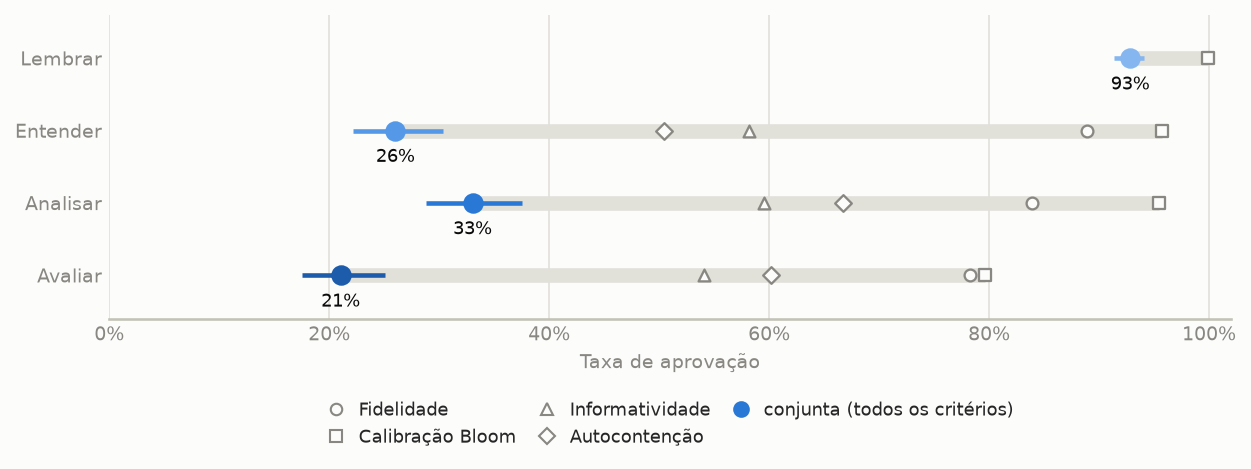

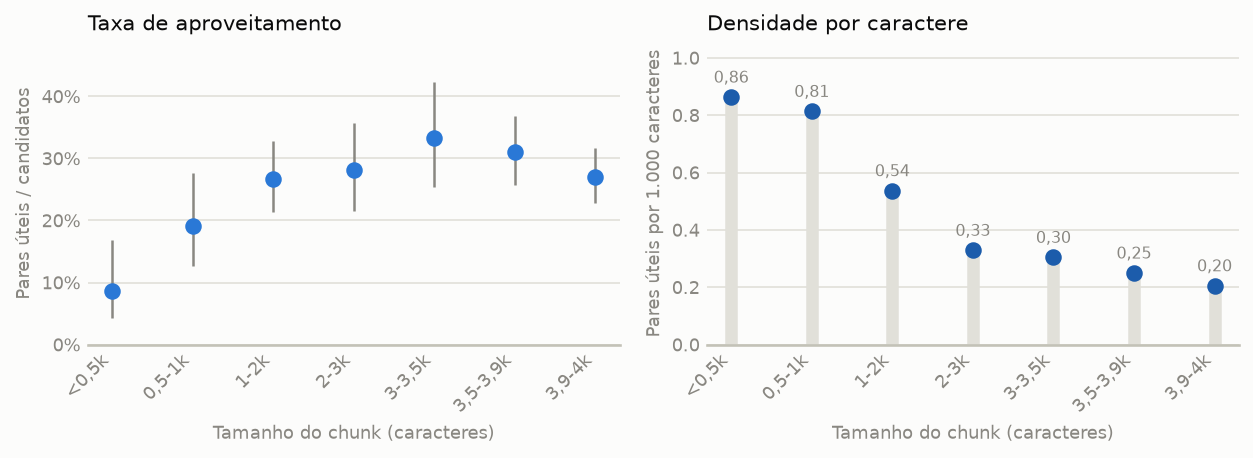

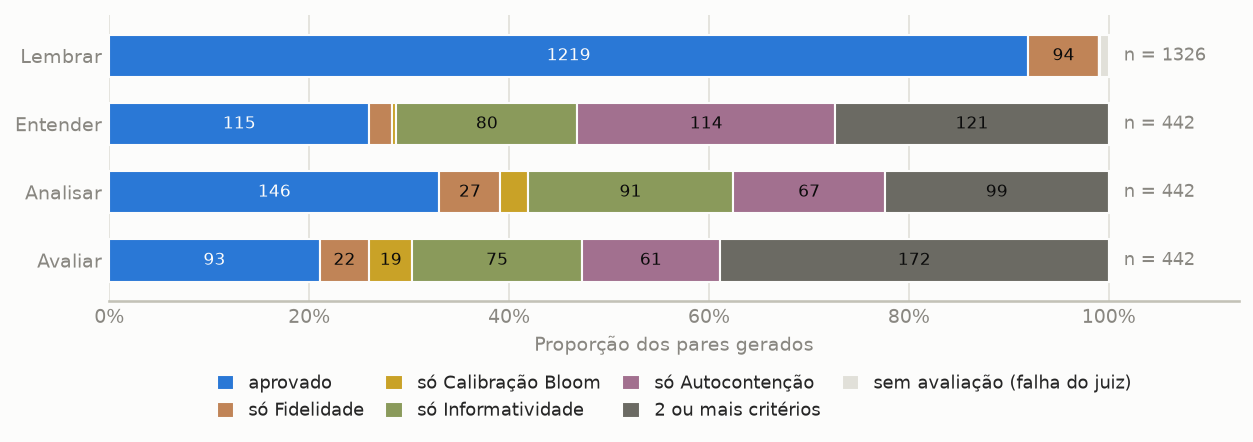

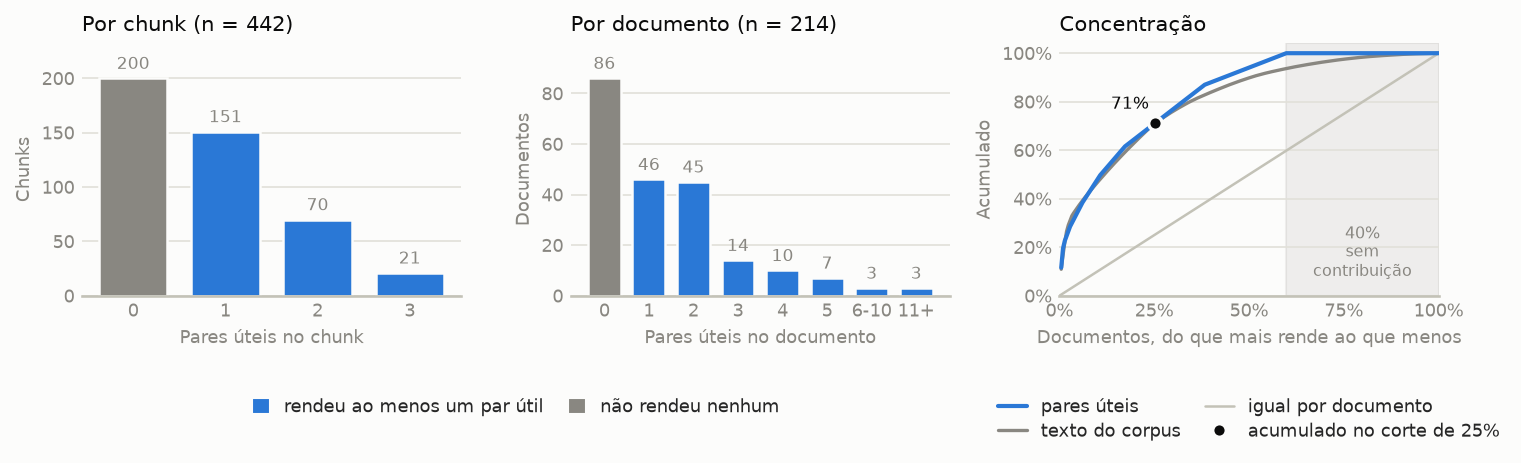

In [22]:
# Figuras para artigo: mesmo tratamento da figura de aprovacao (sem titulo, a
# legenda vai no texto).
fig_conjunta_artigo, _ = plot_marginal_vs_joint(approval, joint, figsize=(8.5, 3.4))
caminho_conjunta = FIG_DIR / f"marginal-vs-conjunta-{RUN_ID}.pdf"
fig_conjunta_artigo.savefig(
    caminho_conjunta, facecolor=fig_conjunta_artigo.get_facecolor(), bbox_inches="tight"
)
fig_conjunta_artigo.savefig(
    caminho_conjunta.with_suffix(".png"), dpi=300,
    facecolor=fig_conjunta_artigo.get_facecolor(), bbox_inches="tight",
)

fig_chunk_artigo, _ = plot_chunk_yield(faixas, figsize=(8.5, 3.2))
caminho_chunk = FIG_DIR / f"rendimento-chunk-{RUN_ID}.pdf"
fig_chunk_artigo.savefig(
    caminho_chunk, facecolor=fig_chunk_artigo.get_facecolor(), bbox_inches="tight"
)
fig_chunk_artigo.savefig(
    caminho_chunk.with_suffix(".png"), dpi=300,
    facecolor=fig_chunk_artigo.get_facecolor(), bbox_inches="tight",
)

fig_decomposicao_artigo, _ = plot_rejection_decomposition(decomposicao, figsize=(8.5, 3.2), normalize=True)
caminho_decomposicao = FIG_DIR / f"decomposicao-reprovacao-{RUN_ID}.pdf"
fig_decomposicao_artigo.savefig(
    caminho_decomposicao, facecolor=fig_decomposicao_artigo.get_facecolor(), bbox_inches="tight"
)
fig_decomposicao_artigo.savefig(
    caminho_decomposicao.with_suffix(".png"), dpi=300,
    facecolor=fig_decomposicao_artigo.get_facecolor(), bbox_inches="tight",
)

fig_cobertura_artigo, _ = plot_coverage(
    por_chunk, por_documento, concentracao,
    sem_contribuicao=float(por_documento.loc["0", "fracao"]), figsize=(10.0, 3.1),
    mostrar_orcamento=False,
)
# Sem titulo de painel os `n` saem da figura, entao esta linha e o texto pronto
# para a legenda do artigo.
print(
    f"legenda: {len(chunks)} chunks e {chunks['source_gdrive_id'].nunique()} documentos,"
    f" {int(pairs['util'].sum())} pares úteis. À esquerda a distribuição por chunk, ao"
    " centro por documento, à direita os pares úteis acumulados sobre os documentos"
    " ordenados do que mais rende ao que menos. Tracejada: rendimento igual por"
    " chunk. Diagonal: rendimento igual por documento."
)
caminho_cobertura = FIG_DIR / f"cobertura-corpus-{RUN_ID}.pdf"
fig_cobertura_artigo.savefig(
    caminho_cobertura, facecolor=fig_cobertura_artigo.get_facecolor(), bbox_inches="tight"
)
fig_cobertura_artigo.savefig(
    caminho_cobertura.with_suffix(".png"), dpi=300,
    facecolor=fig_cobertura_artigo.get_facecolor(), bbox_inches="tight",
)

for caminho in (caminho_conjunta, caminho_chunk, caminho_decomposicao,
                caminho_cobertura):
    print(f"figura salva em {caminho.relative_to(REPO_ROOT)} (+ .png 300 dpi)")
plt.show()